# PCA Scaler Comparison: StandardScaler vs MinMaxScaler

This notebook compares the PCA predictor using two preprocessing choices before PCA:

- `StandardScaler`: centers each feature and scales it to unit standard deviation.
- `MinMaxScaler`: maps each feature into a bounded range, usually `[0, 1]`.

The experiment runs the same PCA predictor grid for both scalers. It records performance metrics, weights, portfolio stats, PCA loadings, explained variance, component counts, prediction distributions, and scaler-to-scaler agreement so the expensive runs can be investigated afterward.

## 1. Setup

The path setup makes the notebook work from the repo root or from `research/Mateo/ML_predictor`.

In [2]:
from pathlib import Path
import sys
import time
import json
import itertools

from joblib import Parallel, delayed
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from run_single_case_PCA import run_single_case_PCA

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

cwd = Path.cwd().resolve()
repo_root = cwd
while repo_root.name != "Bluegrey" and repo_root.parent != repo_root:
    repo_root = repo_root.parent

ml_dir = repo_root / "research" / "Mateo" / "ML_predictor"
src_dir = repo_root / "src"

for path in [repo_root, src_dir, ml_dir]:
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

print(f"Repo root: {repo_root}")
print(f"ML directory: {ml_dir}")

Repo root: /Users/mateo/Bluegrey
ML directory: /Users/mateo/Bluegrey/research/Mateo/ML_predictor


## 2. Grid Specification

This is the requested grid:

- `pca_scaler`: `standard`, `minmax`
- `training_years`: `10`
- `pca_n_components`: `[0.7, 0.75, 0.8, 0.85, 0.9]`
- `signal_threshold`: `[0, 0.01, 0.02, 0.03]`
- `start_date`: `2025-01-01`
- `end_date`: `2026-01-01`
- `sharpe_filter_enabled`: `False`

That is 40 walk-forward backtests. The notebook saves artifacts after every successful run.

In [12]:
SYMBOL = "ECH"
ASSET_CLASS = "STK"
INITIAL_CAPITAL = 1_000_000
EXECUTION_DELAY = 1

SCALERS = ["standard", "minmax"]
PCA_N_COMPONENTS_GRID = [0.7, 0.75, 0.8, 0.85, 0.9]
SIGNAL_THRESHOLD_GRID = [0, 0.01, 0.02, 0.03]

COMMON_PARAMS = {
    "symbol": SYMBOL,
    "start_date": "2025-01-01",
    "end_date": "2026-01-01",
    "training_years": 10,
    "download_data": False,
    "sharpe_filter_enabled": False,
    "feature_diagnostics_enabled": True,
    # None records all available original-feature loadings for every retained component/date.
    # Set to an integer such as 20 if the full diagnostics become too large.
    "feature_diagnostics_top_n": None,
    "position_size": 1.0,
    "max_iter": 5000,
    "verbose": False,
}

RUN_GRID = True
N_JOBS = 12
PARALLEL_VERBOSE = 10
SHOW_PROGRESS = False
SAVE_ARTIFACTS = True

OUTPUT_DIR = ml_dir / "test_PCA_scaler_comparison_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Output directory: {OUTPUT_DIR}")

Output directory: /Users/mateo/Bluegrey/research/Mateo/ML_predictor/test_PCA_scaler_comparison_outputs


## 3. Helper Functions

These helpers run one case through `run_single_case_PCA`, compute comparable metrics, extract PCA diagnostics, and save the heavy artifacts. The runner is used as the execution surface so this notebook stays aligned with your single-case workflow.

In [4]:
def safe_value(value):
    if isinstance(value, (float, np.floating)):
        value = float(value)
        if value.is_integer():
            return str(int(value))
        return f"{value:g}".replace(".", "p")
    return str(value)


def make_run_id(symbol: str, scaler: str, pca_n_components, signal_threshold) -> str:
    return (
        f"{symbol}_scaler-{scaler}"
        f"_pca-{safe_value(pca_n_components)}"
        f"_sig-{safe_value(signal_threshold)}"
    )


def annualized_sharpe(returns: pd.Series, periods_per_year: int = 252) -> float:
    returns = returns.dropna()
    vol = returns.std()
    if vol == 0 or np.isnan(vol):
        return np.nan
    return np.sqrt(periods_per_year) * returns.mean() / vol


def annualized_sortino(returns: pd.Series, periods_per_year: int = 252) -> float:
    returns = returns.dropna()
    downside = returns[returns < 0]
    downside_vol = downside.std()
    if downside_vol == 0 or np.isnan(downside_vol):
        return np.nan
    return np.sqrt(periods_per_year) * returns.mean() / downside_vol


def max_drawdown(equity: pd.Series) -> float:
    return (equity / equity.cummax() - 1.0).min()


def summarize_performance(run_id: str, params: dict, stats: pd.DataFrame, weights: pd.DataFrame, strategy) -> dict:
    gross_return_pct = (stats["gross_equity"].iloc[-1] / INITIAL_CAPITAL - 1.0) * 100
    net_return_pct = (stats["net_equity"].iloc[-1] / INITIAL_CAPITAL - 1.0) * 100
    benchmark_return_pct = (stats["cum_benchmark"].iloc[-1] - 1.0) * 100

    gross_bar_returns = stats["gross_returns"].iloc[1:]
    exposure = weights.abs().sum(axis=1)
    turnover = weights.diff().abs().sum(axis=1).fillna(0)

    prediction_counts = pd.Series(dtype=float)
    if strategy.weight_diagnostics_ is not None and "prediction" in strategy.weight_diagnostics_.columns:
        prediction_counts = strategy.weight_diagnostics_["prediction"].value_counts(normalize=True).sort_index() * 100

    return {
        "run_id": run_id,
        "symbol": params["symbol"],
        "pca_scaler": params["pca_scaler"],
        "pca_n_components": params["pca_n_components"],
        "signal_threshold": params["signal_threshold"],
        "training_years": params["training_years"],
        "gross_return_pct": gross_return_pct,
        "net_return_pct": net_return_pct,
        "benchmark_return_pct": benchmark_return_pct,
        "excess_vs_benchmark_pct": net_return_pct - benchmark_return_pct,
        "max_drawdown_pct": max_drawdown(stats["net_equity"]) * 100,
        "net_sharpe": annualized_sharpe(stats["net_returns"]),
        "net_sortino": annualized_sortino(stats["net_returns"]),
        "win_rate_pct": (gross_bar_returns > 0).mean() * 100,
        "loss_rate_pct": (gross_bar_returns < 0).mean() * 100,
        "zero_rate_pct": (gross_bar_returns == 0).mean() * 100,
        "active_days_pct": (exposure > 0).mean() * 100,
        "long_days_pct": (weights.sum(axis=1) > 0).mean() * 100,
        "short_days_pct": (weights.sum(axis=1) < 0).mean() * 100,
        "flat_days_pct": (weights.sum(axis=1) == 0).mean() * 100,
        "average_abs_exposure": exposure.mean(),
        "average_daily_turnover": turnover.mean(),
        "total_fees_paid": stats["cumulative_costs"].iloc[-1],
        "prediction_minus1_pct": prediction_counts.get(-1.0, 0.0),
        "prediction_0_pct": prediction_counts.get(0.0, 0.0),
        "prediction_plus1_pct": prediction_counts.get(1.0, 0.0),
    }

In [5]:
def component_summary_from_diagnostics(pca_diag: pd.DataFrame) -> pd.DataFrame:
    if pca_diag is None or pca_diag.empty:
        return pd.DataFrame()

    component_rows = pca_diag.drop_duplicates(["prediction_date", "component"])
    return (
        component_rows
        .groupby("prediction_date")
        .agg(
            n_components=("n_components", "max"),
            cumulative_explained_variance=("cumulative_explained_variance", "max"),
            pc1_explained_variance=("explained_variance_ratio", "first"),
        )
    )


def explained_variance_by_component(pca_diag: pd.DataFrame) -> pd.DataFrame:
    if pca_diag is None or pca_diag.empty:
        return pd.DataFrame()

    component_rows = pca_diag.drop_duplicates(["prediction_date", "component"])
    return (
        component_rows
        .groupby("component")
        .agg(
            mean_explained_variance=("explained_variance_ratio", "mean"),
            std_explained_variance=("explained_variance_ratio", "std"),
            mean_cumulative_explained_variance=("cumulative_explained_variance", "mean"),
        )
        .sort_index(key=lambda idx: idx.str.replace("PC", "").astype(int))
    )


def loading_summary_from_diagnostics(pca_diag: pd.DataFrame) -> pd.DataFrame:
    if pca_diag is None or pca_diag.empty:
        return pd.DataFrame()

    summary = (
        pca_diag
        .groupby("feature")
        .agg(
            mean_abs_loading=("abs_loading", "mean"),
            median_abs_loading=("abs_loading", "median"),
            max_abs_loading=("abs_loading", "max"),
            loading_std=("loading", "std"),
            appearances=("feature", "size"),
            mean_rank=("rank", "mean"),
        )
        .sort_values("mean_abs_loading", ascending=False)
    )
    summary["appearance_pct"] = summary["appearances"] / max(summary["appearances"].sum(), 1) * 100
    return summary


def loading_stability_by_component(pca_diag: pd.DataFrame) -> pd.DataFrame:
    if pca_diag is None or pca_diag.empty:
        return pd.DataFrame()

    return (
        pca_diag
        .groupby(["component", "feature"])
        .agg(
            mean_abs_loading=("abs_loading", "mean"),
            std_abs_loading=("abs_loading", "std"),
            mean_signed_loading=("loading", "mean"),
            std_signed_loading=("loading", "std"),
            mean_rank=("rank", "mean"),
            observations=("prediction_date", "nunique"),
        )
        .reset_index()
        .sort_values(["component", "mean_abs_loading"], ascending=[True, False])
    )

In [6]:
def save_case_artifacts(run_id: str, artifacts: dict) -> None:
    run_dir = OUTPUT_DIR / run_id
    run_dir.mkdir(parents=True, exist_ok=True)

    artifacts["stats"].to_pickle(run_dir / "portfolio_stats.pkl")
    artifacts["weights"].to_pickle(run_dir / "weights.pkl")
    artifacts["pca_diagnostics"].to_pickle(run_dir / "pca_diagnostics.pkl")
    artifacts["component_summary"].to_pickle(run_dir / "component_summary.pkl")
    artifacts["explained_variance"].to_pickle(run_dir / "explained_variance.pkl")
    artifacts["loading_summary"].to_pickle(run_dir / "loading_summary.pkl")
    artifacts["loading_stability"].to_pickle(run_dir / "loading_stability.pkl")
    artifacts["weight_diagnostics"].to_pickle(run_dir / "weight_diagnostics.pkl")

    with open(run_dir / "metrics.json", "w") as f:
        json.dump(artifacts["metrics"], f, indent=2, default=str)


def run_one_case(pca_scaler: str, pca_n_components, signal_threshold: float) -> dict:
    run_id = make_run_id(SYMBOL, pca_scaler, pca_n_components, signal_threshold)

    print(f"Running {run_id}")
    start = time.time()

    runner_artifacts = run_single_case_PCA(
        symbol=SYMBOL,
        asset_class=ASSET_CLASS,
        start_date=COMMON_PARAMS["start_date"],
        end_date=COMMON_PARAMS["end_date"],
        signal_threshold=signal_threshold,
        pca_n_components=pca_n_components,
        pca_scaler=pca_scaler,
        training_years=COMMON_PARAMS["training_years"],
        sharpe_filter_enabled=COMMON_PARAMS["sharpe_filter_enabled"],
        feature_diagnostics_enabled=COMMON_PARAMS["feature_diagnostics_enabled"],
        feature_diagnostics_top_n=COMMON_PARAMS["feature_diagnostics_top_n"],
        position_size=COMMON_PARAMS["position_size"],
        initial_capital=INITIAL_CAPITAL,
        max_iter=COMMON_PARAMS["max_iter"],
        execution_delay=EXECUTION_DELAY,
        verbose=COMMON_PARAMS["verbose"],
        show_progress=SHOW_PROGRESS,
        show_tearsheet=False,
        return_artifacts=True,
    )

    strategy = runner_artifacts["strategy"]
    weights = runner_artifacts["weights"]
    stats = runner_artifacts["stats"]

    pca_diag = strategy.feature_selection_diagnostics_.copy()
    component_summary = component_summary_from_diagnostics(pca_diag)
    explained_variance = explained_variance_by_component(pca_diag)
    loading_summary = loading_summary_from_diagnostics(pca_diag)
    loading_stability = loading_stability_by_component(pca_diag)
    weight_diagnostics = strategy.weight_diagnostics_.copy() if strategy.weight_diagnostics_ is not None else pd.DataFrame()

    metrics = summarize_performance(run_id, runner_artifacts["params"], stats, weights, strategy)
    metrics.update({
        "elapsed_seconds": time.time() - start,
        "mean_retained_components": component_summary["n_components"].mean() if not component_summary.empty else np.nan,
        "min_retained_components": component_summary["n_components"].min() if not component_summary.empty else np.nan,
        "max_retained_components": component_summary["n_components"].max() if not component_summary.empty else np.nan,
        "mean_cumulative_explained_variance": component_summary["cumulative_explained_variance"].mean() if not component_summary.empty else np.nan,
        "mean_pc1_explained_variance": component_summary["pc1_explained_variance"].mean() if not component_summary.empty else np.nan,
        "diagnostic_rows": len(pca_diag),
    })

    artifacts = {
        **runner_artifacts,
        "run_id": run_id,
        "pca_diagnostics": pca_diag,
        "component_summary": component_summary,
        "explained_variance": explained_variance,
        "loading_summary": loading_summary,
        "loading_stability": loading_stability,
        "weight_diagnostics": weight_diagnostics,
        "metrics": metrics,
    }

    if SAVE_ARTIFACTS:
        save_case_artifacts(run_id, artifacts)

    return artifacts

## 4. Run the Grid

This cell is intentionally time-consuming. It writes each completed case to `test_PCA_scaler_comparison_outputs/`.

In [6]:
grid_artifacts = {}
grid_metrics = []
grid_errors = []

grid_cases = list(itertools.product(SCALERS, PCA_N_COMPONENTS_GRID, SIGNAL_THRESHOLD_GRID))
print(f"Total cases: {len(grid_cases)}")


def run_one_case_safely(case):
    scaler, n_components, signal_threshold = case
    run_id = make_run_id(SYMBOL, scaler, n_components, signal_threshold)
    try:
        artifacts = run_one_case(scaler, n_components, signal_threshold)
        return {"ok": True, "run_id": run_id, "artifacts": artifacts}
    except Exception as exc:
        return {
            "ok": False,
            "run_id": run_id,
            "pca_scaler": scaler,
            "pca_n_components": n_components,
            "signal_threshold": signal_threshold,
            "error": repr(exc),
        }


if RUN_GRID:
    # Same joblib specification as run_grid_case.py: Parallel(..., backend="loky", verbose=...).
    grid_results = Parallel(n_jobs=N_JOBS, backend="loky", verbose=PARALLEL_VERBOSE)(
        delayed(run_one_case_safely)(case)
        for case in grid_cases
    )

    for result in grid_results:
        if result["ok"]:
            grid_artifacts[result["run_id"]] = result["artifacts"]
            grid_metrics.append(result["artifacts"]["metrics"])
        else:
            grid_errors.append({key: value for key, value in result.items() if key != "ok"})

metrics_df = pd.DataFrame(grid_metrics)
errors_df = pd.DataFrame(grid_errors)

if SAVE_ARTIFACTS and not metrics_df.empty:
    metrics_df.to_pickle(OUTPUT_DIR / "grid_metrics.pkl")
    metrics_df.to_csv(OUTPUT_DIR / "grid_metrics.csv", index=False)
if SAVE_ARTIFACTS and not errors_df.empty:
    errors_df.to_csv(OUTPUT_DIR / "grid_errors.csv", index=False)

display(metrics_df.sort_values("net_sharpe", ascending=False).head(10))
display(errors_df)

Total cases: 40


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.


Running ECH_scaler-standard_pca-0p7_sig-0p03
Running ECH_scaler-standard_pca-0p7_sig-0
Running ECH_scaler-standard_pca-0p7_sig-0p01
Running ECH_scaler-standard_pca-0p7_sig-0p02
Running ECH_scaler-standard_pca-0p75_sig-0p02
Running ECH_scaler-standard_pca-0p75_sig-0
Running ECH_scaler-standard_pca-0p75_sig-0p01
Running ECH_scaler-standard_pca-0p8_sig-0
Running ECH_scaler-standard_pca-0p75_sig-0p03
Running ECH_scaler-standard_pca-0p8_sig-0p01
Running ECH_scaler-standard_pca-0p8_sig-0p02
Running ECH_scaler-standard_pca-0p8_sig-0p03
Running ECH_scaler-standard_pca-0p85_sig-0


[Parallel(n_jobs=12)]: Done   1 tasks      | elapsed:  9.2min


Running ECH_scaler-standard_pca-0p85_sig-0p01
Running ECH_scaler-standard_pca-0p85_sig-0p02
Running ECH_scaler-standard_pca-0p85_sig-0p03
Running ECH_scaler-standard_pca-0p9_sig-0
Running ECH_scaler-standard_pca-0p9_sig-0p01
Running ECH_scaler-standard_pca-0p9_sig-0p02
Running ECH_scaler-standard_pca-0p9_sig-0p03


...

[Parallel(n_jobs=12)]: Done  27 out of  40 | elapsed: 55.3min remaining: 26.6min


Running ECH_scaler-minmax_pca-0p9_sig-0p03


[Parallel(n_jobs=12)]: Done  32 out of  40 | elapsed: 69.2min remaining: 17.3min
[Parallel(n_jobs=12)]: Done  37 out of  40 | elapsed: 80.8min remaining:  6.5min
[Parallel(n_jobs=12)]: Done  40 out of  40 | elapsed: 90.9min finished


,run_id,symbol,pca_scaler,pca_n_components,signal_threshold,training_years,gross_return_pct,net_return_pct,benchmark_return_pct,excess_vs_benchmark_pct,max_drawdown_pct,net_sharpe,net_sortino,win_rate_pct,loss_rate_pct,zero_rate_pct,active_days_pct,long_days_pct,short_days_pct,flat_days_pct,average_abs_exposure,average_daily_turnover,total_fees_paid,prediction_minus1_pct,prediction_0_pct,prediction_plus1_pct,elapsed_seconds,mean_retained_components,min_retained_components,max_retained_components,mean_cumulative_explained_variance,mean_pc1_explained_variance,diagnostic_rows
14,ECH_scaler-standard_pca-0p85_sig-0p02,ECH,standard,0.85,0.02,10,21.502566,20.448604,65.173061,-44.724457,-3.242744,1.959530,1.779311,6.425703,3.212851,90.361446,9.6,6.0,3.6,90.4,0.096,0.168,10539.625422,3.6,90.4,6.0,1564.414479,42.692,42,43,0.852081,0.337569,4618889
9,ECH_scaler-standard_pca-0p8_sig-0p01,ECH,standard,0.80,0.01,10,37.571891,33.543593,65.173061,-31.629468,-7.033397,1.907588,2.555215,24.497992,18.473896,57.028112,44.0,23.6,20.4,56.0,0.440,0.616,40282.984159,20.4,56.0,23.6,1487.452959,27.112,27,28,0.801492,0.337569,2933254
13,ECH_scaler-standard_pca-0p85_sig-0p01,ECH,standard,0.85,0.01,10,27.309230,23.301519,65.173061,-41.871541,-8.981629,1.410711,2.131644,23.293173,22.088353,54.618474,46.4,20.8,25.6,53.6,0.464,0.648,40077.110063,25.6,53.6,20.8,2216.025692,42.692,42,43,0.852081,0.337569,4618889
7,ECH_scaler-standard_pca-0p75_sig-0p03,ECH,standard,0.75,0.03,10,1.536724,1.410661,65.173061,-63.762399,-0.019685,1.292988,183.246030,1.204819,0.000000,98.795181,1.2,1.2,0.0,98.8,0.012,0.024,1260.623079,0.0,98.8,1.2,1013.992759,17.528,17,18,0.753789,0.337569,1896386
22,ECH_scaler-minmax_pca-0p7_sig-0p02,ECH,minmax,0.70,0.02,10,1.229016,1.184522,65.173061,-63.988539,-0.020529,0.986681,NaN,0.401606,0.000000,99.598394,0.4,0.4,0.0,99.6,0.004,0.008,444.945191,0.0,99.6,0.4,688.032344,6.000,6,6,0.704652,0.291916,649140
31,ECH_scaler-minmax_pca-0p8_sig-0p03,ECH,minmax,0.80,0.03,10,4.255027,4.026565,65.173061,-61.146496,-2.040844,0.844381,0.499082,1.606426,0.803213,97.590361,2.4,0.8,1.6,97.6,0.024,0.040,2284.623592,1.6,97.6,0.8,1537.879766,12.556,12,13,0.805882,0.291916,1358467
4,ECH_scaler-standard_pca-0p75_sig-0,ECH,standard,0.75,0.00,10,22.066729,17.850307,65.173061,-47.322754,-19.972370,0.840850,1.381985,52.208835,44.578313,3.212851,99.6,36.0,63.6,0.4,0.996,0.640,42164.221415,63.6,0.4,36.0,866.184219,17.528,17,18,0.753789,0.337569,1896386
18,ECH_scaler-standard_pca-0p9_sig-0p02,ECH,standard,0.90,0.02,10,10.188421,9.120361,65.173061,-56.052699,-4.472660,0.808096,0.512872,6.024096,3.614458,90.361446,9.6,4.8,4.8,90.4,0.096,0.176,10680.599129,4.8,90.4,4.8,1915.039806,62.836,62,64,0.900539,0.337569,6798277
17,ECH_scaler-standard_pca-0p9_sig-0p01,ECH,standard,0.90,0.01,10,16.050257,12.656871,65.173061,-52.516190,-7.671228,0.786054,0.894913,26.104418,17.269076,56.626506,44.0,18.4,25.6,56.0,0.440,0.584,33933.857621,25.6,56.0,18.4,2391.744282,62.836,62,64,0.900539,0.337569,6798277
10,ECH_scaler-standard_pca-0p8_sig-0p02,ECH,standard,0.80,0.02,10,5.784372,4.647025,65.173061,-60.526036,-6.300632,0.662581,0.466016,5.622490,5.220884,89.156627,10.8,7.2,3.6,89.2,0.108,0.192,11373.472430,3.6,89.2,7.2,1416.081693,27.112,27,28,0.801492,0.337569,2933254


""


## 5. Performance Leaderboards

The same grid can look different depending on the ranking metric. I usually inspect net Sharpe first, then net return, drawdown, and fees.

In [7]:
leaderboard_cols = [
    "run_id", "pca_scaler", "pca_n_components", "signal_threshold",
    "net_return_pct", "gross_return_pct", "benchmark_return_pct", "excess_vs_benchmark_pct",
    "net_sharpe", "net_sortino", "max_drawdown_pct", "total_fees_paid",
    "win_rate_pct", "loss_rate_pct", "zero_rate_pct",
    "long_days_pct", "short_days_pct", "flat_days_pct", "average_abs_exposure",
    "prediction_minus1_pct", "prediction_plus1_pct", "prediction_0_pct",
    "active_days_pct", "average_daily_turnover", "mean_retained_components",
    "mean_cumulative_explained_variance", "elapsed_seconds",
]

print("Best performers regarding NET SHARPE RATIO")
display(metrics_df[leaderboard_cols].sort_values("net_sharpe", ascending=False).head(15).round(2))
print("\nBest performers regarding NET RETURN")
display(metrics_df[leaderboard_cols].sort_values("net_return_pct", ascending=False).head(15).round(2))
print("\nBest performers regarding MAX DRAWDOWN")
display(metrics_df[leaderboard_cols].sort_values("max_drawdown_pct", ascending=False).head(15).round(2))

Best performers regarding NET SHARPE RATIO


,run_id,pca_scaler,pca_n_components,signal_threshold,net_return_pct,gross_return_pct,benchmark_return_pct,excess_vs_benchmark_pct,net_sharpe,net_sortino,max_drawdown_pct,total_fees_paid,win_rate_pct,loss_rate_pct,zero_rate_pct,long_days_pct,short_days_pct,flat_days_pct,average_abs_exposure,prediction_minus1_pct,prediction_plus1_pct,prediction_0_pct,active_days_pct,average_daily_turnover,mean_retained_components,mean_cumulative_explained_variance,elapsed_seconds
14,ECH_scaler-standard_pca-0p85_sig-0p02,standard,0.85,0.02,20.45,21.50,65.17,-44.72,1.96,1.78,-3.24,10539.63,6.43,3.21,90.36,6.0,3.6,90.4,0.10,3.6,6.0,90.4,9.6,0.17,42.69,0.85,1564.41
9,ECH_scaler-standard_pca-0p8_sig-0p01,standard,0.80,0.01,33.54,37.57,65.17,-31.63,1.91,2.56,-7.03,40282.98,24.50,18.47,57.03,23.6,20.4,56.0,0.44,20.4,23.6,56.0,44.0,0.62,27.11,0.80,1487.45
13,ECH_scaler-standard_pca-0p85_sig-0p01,standard,0.85,0.01,23.30,27.31,65.17,-41.87,1.41,2.13,-8.98,40077.11,23.29,22.09,54.62,20.8,25.6,53.6,0.46,25.6,20.8,53.6,46.4,0.65,42.69,0.85,2216.03
7,ECH_scaler-standard_pca-0p75_sig-0p03,standard,0.75,0.03,1.41,1.54,65.17,-63.76,1.29,183.25,-0.02,1260.62,1.20,0.00,98.80,1.2,0.0,98.8,0.01,0.0,1.2,98.8,1.2,0.02,17.53,0.75,1013.99
22,ECH_scaler-minmax_pca-0p7_sig-0p02,minmax,0.70,0.02,1.18,1.23,65.17,-63.99,0.99,NaN,-0.02,444.95,0.40,0.00,99.60,0.4,0.0,99.6,0.00,0.0,0.4,99.6,0.4,0.01,6.00,0.70,688.03
31,ECH_scaler-minmax_pca-0p8_sig-0p03,minmax,0.80,0.03,4.03,4.26,65.17,-61.15,0.84,0.50,-2.04,2284.62,1.61,0.80,97.59,0.8,1.6,97.6,0.02,1.6,0.8,97.6,2.4,0.04,12.56,0.81,1537.88
4,ECH_scaler-standard_pca-0p75_sig-0,standard,0.75,0.00,17.85,22.07,65.17,-47.32,0.84,1.38,-19.97,42164.22,52.21,44.58,3.21,36.0,63.6,0.4,1.00,63.6,36.0,0.4,99.6,0.64,17.53,0.75,866.18
18,ECH_scaler-standard_pca-0p9_sig-0p02,standard,0.90,0.02,9.12,10.19,65.17,-56.05,0.81,0.51,-4.47,10680.60,6.02,3.61,90.36,4.8,4.8,90.4,0.10,4.8,4.8,90.4,9.6,0.18,62.84,0.90,1915.04
17,ECH_scaler-standard_pca-0p9_sig-0p01,standard,0.90,0.01,12.66,16.05,65.17,-52.52,0.79,0.89,-7.67,33933.86,26.10,17.27,56.63,18.4,25.6,56.0,0.44,25.6,18.4,56.0,44.0,0.58,62.84,0.90,2391.74
10,ECH_scaler-standard_pca-0p8_sig-0p02,standard,0.80,0.02,4.65,5.78,65.17,-60.53,0.66,0.47,-6.30,11373.47,5.62,5.22,89.16,7.2,3.6,89.2,0.11,3.6,7.2,89.2,10.8,0.19,27.11,0.80,1416.08



Best performers regarding NET RETURN


,run_id,pca_scaler,pca_n_components,signal_threshold,net_return_pct,gross_return_pct,benchmark_return_pct,excess_vs_benchmark_pct,net_sharpe,net_sortino,max_drawdown_pct,total_fees_paid,win_rate_pct,loss_rate_pct,zero_rate_pct,long_days_pct,short_days_pct,flat_days_pct,average_abs_exposure,prediction_minus1_pct,prediction_plus1_pct,prediction_0_pct,active_days_pct,average_daily_turnover,mean_retained_components,mean_cumulative_explained_variance,elapsed_seconds
9,ECH_scaler-standard_pca-0p8_sig-0p01,standard,0.80,0.01,33.54,37.57,65.17,-31.63,1.91,2.56,-7.03,40282.98,24.50,18.47,57.03,23.6,20.4,56.0,0.44,20.4,23.6,56.0,44.0,0.62,27.11,0.80,1487.45
13,ECH_scaler-standard_pca-0p85_sig-0p01,standard,0.85,0.01,23.30,27.31,65.17,-41.87,1.41,2.13,-8.98,40077.11,23.29,22.09,54.62,20.8,25.6,53.6,0.46,25.6,20.8,53.6,46.4,0.65,42.69,0.85,2216.03
14,ECH_scaler-standard_pca-0p85_sig-0p02,standard,0.85,0.02,20.45,21.50,65.17,-44.72,1.96,1.78,-3.24,10539.63,6.43,3.21,90.36,6.0,3.6,90.4,0.10,3.6,6.0,90.4,9.6,0.17,42.69,0.85,1564.41
4,ECH_scaler-standard_pca-0p75_sig-0,standard,0.75,0.00,17.85,22.07,65.17,-47.32,0.84,1.38,-19.97,42164.22,52.21,44.58,3.21,36.0,63.6,0.4,1.00,63.6,36.0,0.4,99.6,0.64,17.53,0.75,866.18
17,ECH_scaler-standard_pca-0p9_sig-0p01,standard,0.90,0.01,12.66,16.05,65.17,-52.52,0.79,0.89,-7.67,33933.86,26.10,17.27,56.63,18.4,25.6,56.0,0.44,25.6,18.4,56.0,44.0,0.58,62.84,0.90,2391.74
18,ECH_scaler-standard_pca-0p9_sig-0p02,standard,0.90,0.02,9.12,10.19,65.17,-56.05,0.81,0.51,-4.47,10680.60,6.02,3.61,90.36,4.8,4.8,90.4,0.10,4.8,4.8,90.4,9.6,0.18,62.84,0.90,1915.04
10,ECH_scaler-standard_pca-0p8_sig-0p02,standard,0.80,0.02,4.65,5.78,65.17,-60.53,0.66,0.47,-6.30,11373.47,5.62,5.22,89.16,7.2,3.6,89.2,0.11,3.6,7.2,89.2,10.8,0.19,27.11,0.80,1416.08
37,ECH_scaler-minmax_pca-0p9_sig-0p01,minmax,0.90,0.01,4.50,8.31,65.17,-60.67,0.41,0.42,-9.43,38098.23,20.88,16.47,62.65,19.6,18.4,62.0,0.38,18.4,19.6,62.0,38.0,0.62,28.05,0.90,2096.57
31,ECH_scaler-minmax_pca-0p8_sig-0p03,minmax,0.80,0.03,4.03,4.26,65.17,-61.15,0.84,0.50,-2.04,2284.62,1.61,0.80,97.59,0.8,1.6,97.6,0.02,1.6,0.8,97.6,2.4,0.04,12.56,0.81,1537.88
12,ECH_scaler-standard_pca-0p85_sig-0,standard,0.85,0.00,1.84,7.08,65.17,-63.33,0.19,0.30,-23.28,52433.09,48.59,47.79,3.61,46.8,52.4,0.8,0.99,52.4,46.8,0.8,99.2,0.89,42.69,0.85,1899.73



Best performers regarding MAX DRAWDOWN


,run_id,pca_scaler,pca_n_components,signal_threshold,net_return_pct,gross_return_pct,benchmark_return_pct,excess_vs_benchmark_pct,net_sharpe,net_sortino,max_drawdown_pct,total_fees_paid,win_rate_pct,loss_rate_pct,zero_rate_pct,long_days_pct,short_days_pct,flat_days_pct,average_abs_exposure,prediction_minus1_pct,prediction_plus1_pct,prediction_0_pct,active_days_pct,average_daily_turnover,mean_retained_components,mean_cumulative_explained_variance,elapsed_seconds
23,ECH_scaler-minmax_pca-0p7_sig-0p03,minmax,0.70,0.03,0.00,0.00,65.17,-65.17,NaN,NaN,0.00,0.00,0.00,0.00,100.00,0.0,0.0,100.0,0.00,0.0,0.0,100.0,0.0,0.00,6.00,0.70,691.48
7,ECH_scaler-standard_pca-0p75_sig-0p03,standard,0.75,0.03,1.41,1.54,65.17,-63.76,1.29,183.25,-0.02,1260.62,1.20,0.00,98.80,1.2,0.0,98.8,0.01,0.0,1.2,98.8,1.2,0.02,17.53,0.75,1013.99
22,ECH_scaler-minmax_pca-0p7_sig-0p02,minmax,0.70,0.02,1.18,1.23,65.17,-63.99,0.99,NaN,-0.02,444.95,0.40,0.00,99.60,0.4,0.0,99.6,0.00,0.0,0.4,99.6,0.4,0.01,6.00,0.70,688.03
31,ECH_scaler-minmax_pca-0p8_sig-0p03,minmax,0.80,0.03,4.03,4.26,65.17,-61.15,0.84,0.50,-2.04,2284.62,1.61,0.80,97.59,0.8,1.6,97.6,0.02,1.6,0.8,97.6,2.4,0.04,12.56,0.81,1537.88
15,ECH_scaler-standard_pca-0p85_sig-0p03,standard,0.85,0.03,1.33,1.54,65.17,-63.84,0.37,0.10,-2.69,2123.04,1.20,0.80,97.99,0.8,1.2,98.0,0.02,1.2,0.8,98.0,2.0,0.04,42.69,0.85,1250.11
19,ECH_scaler-standard_pca-0p9_sig-0p03,standard,0.90,0.03,-1.69,-1.56,65.17,-66.86,-0.73,-0.13,-2.71,1299.59,0.40,0.80,98.80,0.4,0.8,98.8,0.01,0.8,0.4,98.8,1.2,0.02,62.84,0.90,1676.63
14,ECH_scaler-standard_pca-0p85_sig-0p02,standard,0.85,0.02,20.45,21.50,65.17,-44.72,1.96,1.78,-3.24,10539.63,6.43,3.21,90.36,6.0,3.6,90.4,0.10,3.6,6.0,90.4,9.6,0.17,42.69,0.85,1564.41
11,ECH_scaler-standard_pca-0p8_sig-0p03,standard,0.80,0.03,-1.50,-1.32,65.17,-66.67,-0.37,-0.08,-3.63,1772.18,0.80,1.20,97.99,1.2,0.8,98.0,0.02,0.8,1.2,98.0,2.0,0.03,27.11,0.80,1005.57
39,ECH_scaler-minmax_pca-0p9_sig-0p03,minmax,0.90,0.03,-3.11,-2.93,65.17,-68.28,-1.01,-0.17,-3.67,1777.26,1.20,0.80,97.99,0.8,1.2,98.0,0.02,1.2,0.8,98.0,2.0,0.03,28.05,0.90,1105.14
27,ECH_scaler-minmax_pca-0p75_sig-0p03,minmax,0.75,0.03,-4.20,-4.15,65.17,-69.37,-1.01,-0.09,-4.20,497.17,0.00,0.40,99.60,0.0,0.4,99.6,0.00,0.4,0.0,99.6,0.4,0.01,8.82,0.76,1160.01


## 6. Matched Standard vs MinMax Deltas

For each `(pca_n_components, signal_threshold)` pair, this compares `minmax - standard`. Positive values favor `MinMaxScaler`; negative values favor `StandardScaler`.

In [18]:
compare_metrics = [
    "net_return_pct", "gross_return_pct", "excess_vs_benchmark_pct", "net_sharpe", "net_sortino",
    "max_drawdown_pct", "total_fees_paid", "active_days_pct", "average_daily_turnover",
    "mean_retained_components", "mean_cumulative_explained_variance", "mean_pc1_explained_variance",
]

wide = metrics_df.pivot_table(
    index=["pca_n_components", "signal_threshold"],
    columns="pca_scaler",
    values=compare_metrics,
)

delta_records = []
for metric in compare_metrics:
    if (metric, "minmax") in wide.columns and (metric, "standard") in wide.columns:
        delta = wide[(metric, "minmax")] - wide[(metric, "standard")]
        for idx, value in delta.items():
            delta_records.append({
                "pca_n_components": idx[0],
                "signal_threshold": idx[1],
                "metric": metric,
                "minmax_minus_standard": value,
            })

deltas_df = pd.DataFrame(delta_records)
display(deltas_df.pivot_table(index=["pca_n_components", "signal_threshold"], columns="metric", values="minmax_minus_standard").round(2))

NameError: name 'metrics_df' is not defined

## 7. Heatmaps

These heatmaps show whether each scaler has a stable region of good performance or only a single lucky point.

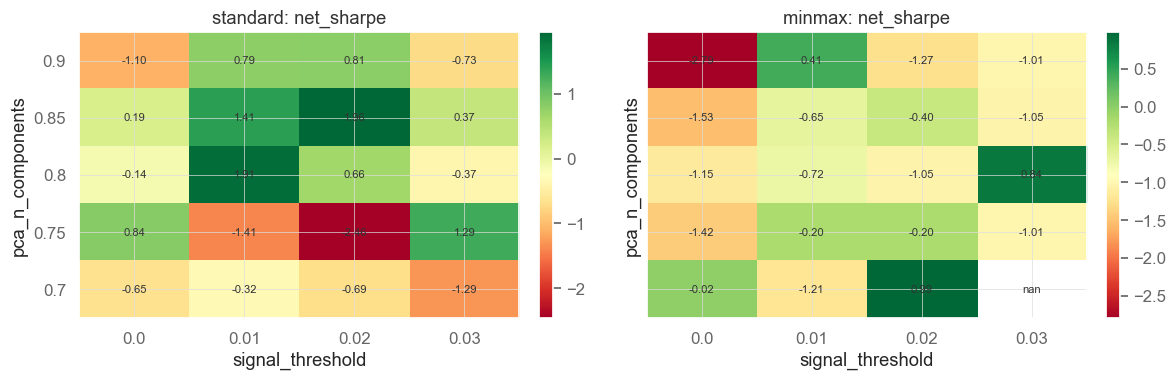

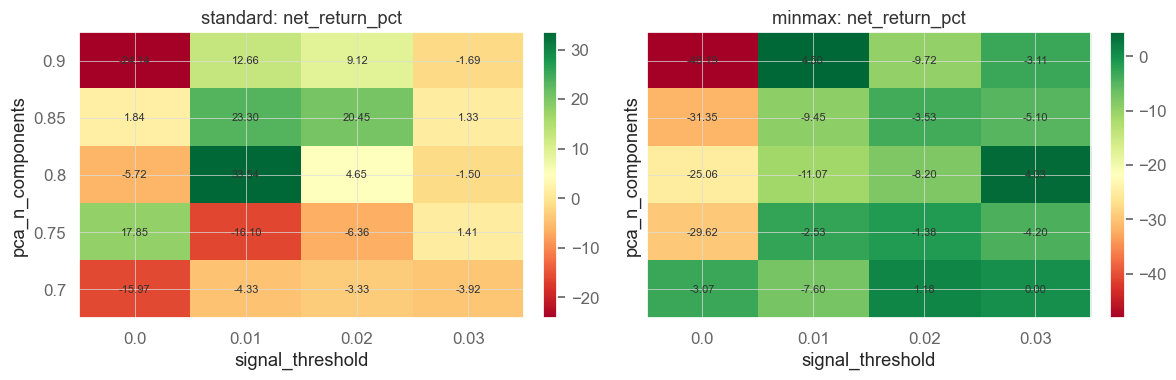

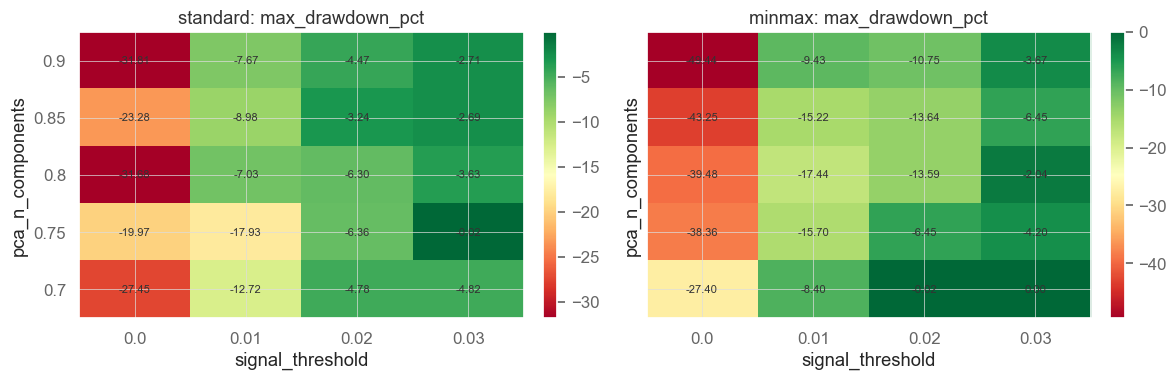

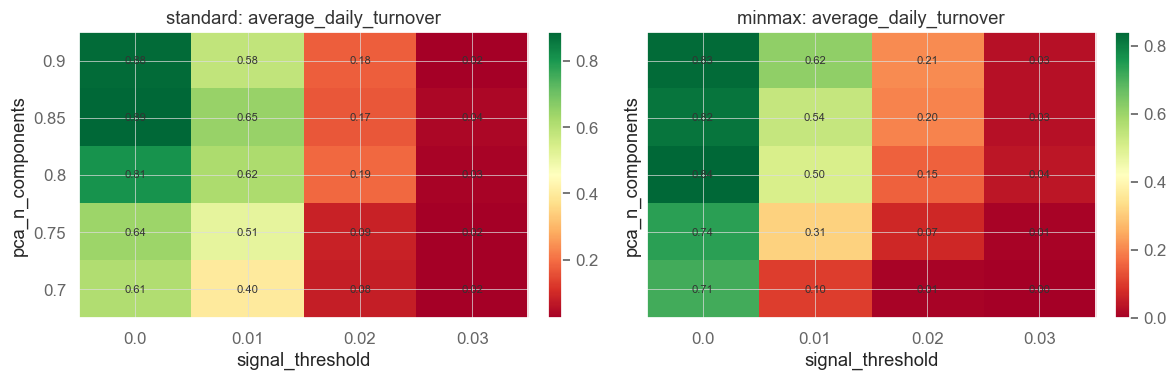

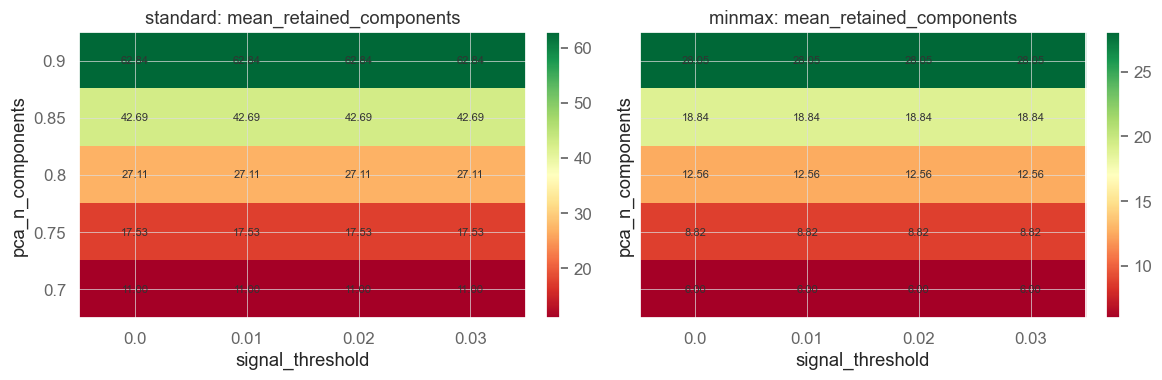

In [9]:
def plot_metric_grid(metric: str):
    fig, axes = plt.subplots(1, len(SCALERS), figsize=(6 * len(SCALERS), 4), sharey=True)
    if len(SCALERS) == 1:
        axes = [axes]

    for ax, scaler in zip(axes, SCALERS):
        pivot = (
            metrics_df[metrics_df["pca_scaler"] == scaler]
            .pivot(index="pca_n_components", columns="signal_threshold", values=metric)
            .sort_index(ascending=False)
        )
        im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn")
        ax.set_title(f"{scaler}: {metric}")
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index)
        ax.set_xlabel("signal_threshold")
        ax.set_ylabel("pca_n_components")
        for y in range(pivot.shape[0]):
            for x in range(pivot.shape[1]):
                ax.text(x, y, f"{pivot.values[y, x]:.2f}", ha="center", va="center", fontsize=8)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


for metric in ["net_sharpe", "net_return_pct", "max_drawdown_pct", "average_daily_turnover", "mean_retained_components"]:
    plot_metric_grid(metric)

## 8. Prediction Agreement and Class Distribution
This checks whether the scalers merely change performance slightly, or whether they produce genuinely different predictions.

In [10]:
agreement_records = []

for n_components in PCA_N_COMPONENTS_GRID:
    for signal_threshold in SIGNAL_THRESHOLD_GRID:
        standard_id = make_run_id(SYMBOL, "standard", n_components, signal_threshold)
        minmax_id = make_run_id(SYMBOL, "minmax", n_components, signal_threshold)
        if standard_id not in grid_artifacts or minmax_id not in grid_artifacts:
            continue

        standard_pred = grid_artifacts[standard_id]["weight_diagnostics"]["prediction"].rename("standard")
        minmax_pred = grid_artifacts[minmax_id]["weight_diagnostics"]["prediction"].rename("minmax")
        pred = pd.concat([standard_pred, minmax_pred], axis=1).dropna()

        agreement_records.append({
            "pca_n_components": n_components,
            "signal_threshold": signal_threshold,
            "prediction_agreement_pct": (pred["standard"] == pred["minmax"]).mean() * 100,
            "directional_agreement_pct": (np.sign(pred["standard"]) == np.sign(pred["minmax"])).mean() * 100,
            "standard_long_pct": (pred["standard"] > 0).mean() * 100,
            "standard_short_pct": (pred["standard"] < 0).mean() * 100,
            "standard_flat_pct": (pred["standard"] == 0).mean() * 100,
            "minmax_long_pct": (pred["minmax"] > 0).mean() * 100,
            "minmax_short_pct": (pred["minmax"] < 0).mean() * 100,
            "minmax_flat_pct": (pred["minmax"] == 0).mean() * 100,
        })

agreement_df = pd.DataFrame(agreement_records)
display(agreement_df.round(3))

,pca_n_components,signal_threshold,prediction_agreement_pct,directional_agreement_pct,standard_long_pct,standard_short_pct,standard_flat_pct,minmax_long_pct,minmax_short_pct,minmax_flat_pct
0,0.70,0.00,68.4,68.4,40.8,59.2,0.0,39.6,60.4,0.0
1,0.70,0.01,70.8,70.8,13.6,14.8,71.6,4.0,1.6,94.4
2,0.70,0.02,93.6,93.6,0.4,5.6,94.0,0.4,0.0,99.6
3,0.70,0.03,98.4,98.4,0.0,1.6,98.4,0.0,0.0,100.0
4,0.75,0.00,58.8,58.8,36.0,63.6,0.4,38.8,61.2,0.0
5,0.75,0.01,61.2,61.2,10.0,24.0,66.0,9.2,12.4,78.4
6,0.75,0.02,92.4,92.4,1.2,3.2,95.6,2.0,2.4,95.6
7,0.75,0.03,98.4,98.4,1.2,0.0,98.8,0.0,0.4,99.6
8,0.80,0.00,56.0,56.0,46.8,52.0,1.2,39.6,60.4,0.0
9,0.80,0.01,49.2,49.2,23.6,20.4,56.0,18.4,18.8,62.8


## 9. PCA Component Counts and Explained Variance
For variance-threshold PCA, the actual number of retained components is not fixed. The scaler choice can change the variance spectrum and therefore change how many components PCA keeps.

mean_cumulative_explained_variance          mean_pc1_explained_variance          mean_retained_components         
pca_scaler                                                    minmax standard                      minmax standard                   minmax standard
pca_n_components signal_threshold                                                                                                                   
0.70             0.00                                         0.7047   0.7052                      0.2919   0.3376                    6.000   11.000
                 0.01                                         0.7047   0.7052                      0.2919   0.3376                    6.000   11.000
                 0.02                                         0.7047   0.7052                      0.2919   0.3376                    6.000   11.000
                 0.03                                         0.7047   0.7052                      0.2919   0.3376                    6.000   11.000
0.75             0.00                                         0.7621   0.7538                      0.2919   0.3376                    8.816   17.528
                 0.01                                         0.7621   0.7538                      0.2919   0.3376                    8.816   17.528
                 0.02                                         0.7621   0.7538                      0.2919   0.3376                    8.816   17.528
                 0.03                                         0.7621   0.7538                      0.2919   0.3376                    8.816   17.528
0.80             0.00                                         0.8059   0.8015                      0.2919   0.3376                   12.556   27.112
                 0.01                                         0.8059   0.8015                      0.2919   0.3376                   12.556   27.112
                 0.02                                         0.8059   0.8015                      0.2919   0.3376                   12.556   27.112
                 0.03                                         0.8059   0.8015                      0.2919   0.3376                   12.556   27.112
0.85             0.00                                         0.8545   0.8521                      0.2919   0.3376                   18.844   42.692
                 0.01                                         0.8545   0.8521                      0.2919   0.3376                   18.844   42.692
                 0.02                                         0.8545   0.8521                      0.2919   0.3376                   18.844   42.692
                 0.03                                         0.8545   0.8521                      0.2919   0.3376                   18.844   42.692
0.90             0.00                                         0.9009   0.9005                      0.2919   0.3376                   28.052   62.836
                 0.01                                         0.9009   0.9005                      0.2919   0.3376                   28.052   62.836
                 0.02                                         0.9009   0.9005                      0.2919   0.3376                   28.052   62.836
                 0.03                                         0.9009   0.9005                      0.2919   0.3376                   28.052   62.836

Best net Sharpe run: ECH_scaler-standard_pca-0p85_sig-0p02


,n_components,cumulative_explained_variance,pc1_explained_variance
count,250.0000,250.0000,250.0000
mean,42.6920,0.8521,0.3376
std,0.4626,0.0006,0.0008
min,42.0000,0.8501,0.3368
25%,42.0000,0.8521,0.3371
50%,43.0000,0.8522,0.3372
75%,43.0000,0.8523,0.3375
max,43.0000,0.8527,0.3402


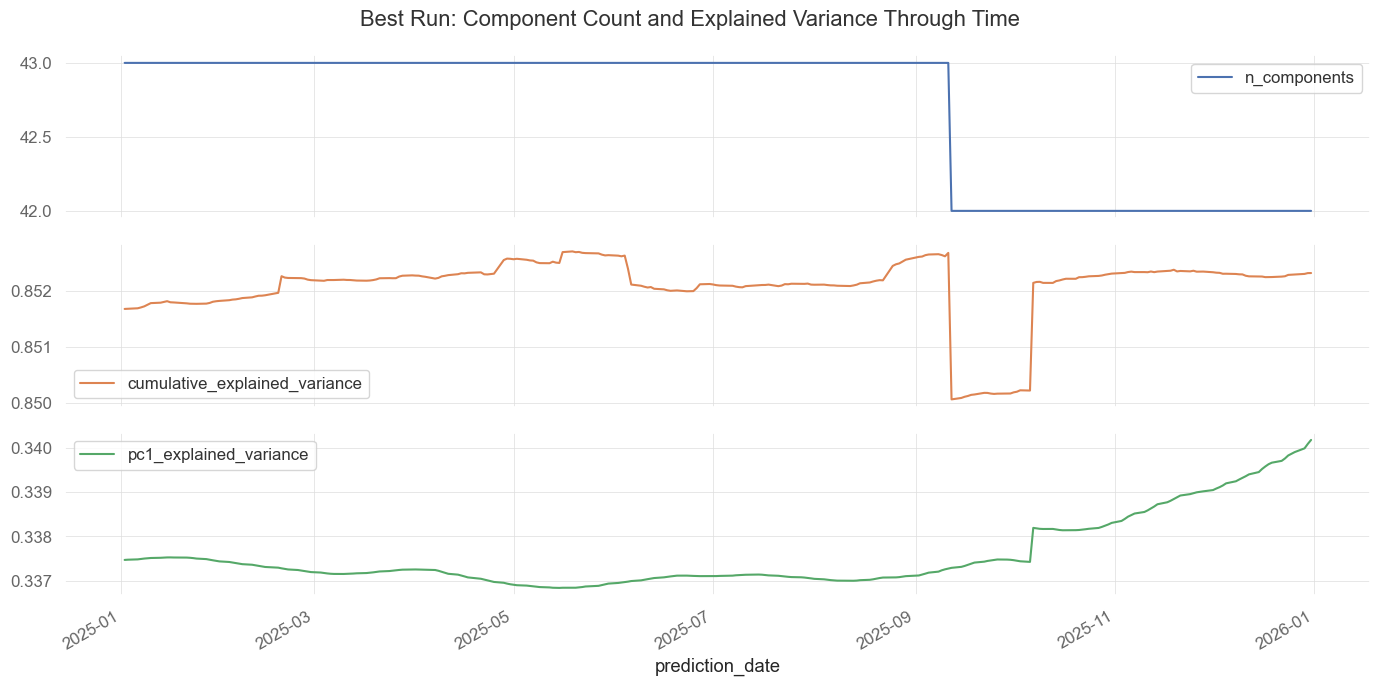

In [11]:
component_grid = metrics_df.pivot_table(
    index=["pca_n_components", "signal_threshold"],
    columns="pca_scaler",
    values=["mean_retained_components", "mean_cumulative_explained_variance", "mean_pc1_explained_variance"],
)
display(component_grid.round(4))

best_run_id = metrics_df.sort_values("net_sharpe", ascending=False).iloc[0]["run_id"]
print(f"Best net Sharpe run: {best_run_id}")

best_component_summary = grid_artifacts[best_run_id]["component_summary"]
display(best_component_summary.describe().round(4))

ax = best_component_summary[["n_components", "cumulative_explained_variance", "pc1_explained_variance"]].plot(
    subplots=True,
    figsize=(14, 7),
    title="Best Run: Component Count and Explained Variance Through Time",
)
plt.tight_layout()
plt.show()

## 10. PCA Loading Diagnostics

PCA signs are arbitrary: a component can flip sign without changing the model geometry. For scaler comparison, focus mostly on `abs_loading` and average absolute loadings.

,run_id,pca_scaler,pca_n_components,signal_threshold,net_return_pct,gross_return_pct,benchmark_return_pct,excess_vs_benchmark_pct,net_sharpe,net_sortino,max_drawdown_pct,total_fees_paid,win_rate_pct,loss_rate_pct,zero_rate_pct,long_days_pct,short_days_pct,flat_days_pct,average_abs_exposure,prediction_minus1_pct,prediction_plus1_pct,prediction_0_pct,active_days_pct,average_daily_turnover,mean_retained_components,mean_cumulative_explained_variance,elapsed_seconds
14,ECH_scaler-standard_pca-0p85_sig-0p02,standard,0.85,0.02,20.4486,21.5026,65.1731,-44.7245,1.9595,1.7793,-3.2427,10539.6254,6.4257,3.2129,90.3614,6.0,3.6,90.4,0.096,3.6,6.0,90.4,9.6,0.168,42.692,0.8521,1564.4145
22,ECH_scaler-minmax_pca-0p7_sig-0p02,minmax,0.70,0.02,1.1845,1.2290,65.1731,-63.9885,0.9867,NaN,-0.0205,444.9452,0.4016,0.0000,99.5984,0.4,0.0,99.6,0.004,0.0,0.4,99.6,0.4,0.008,6.000,0.7047,688.0323


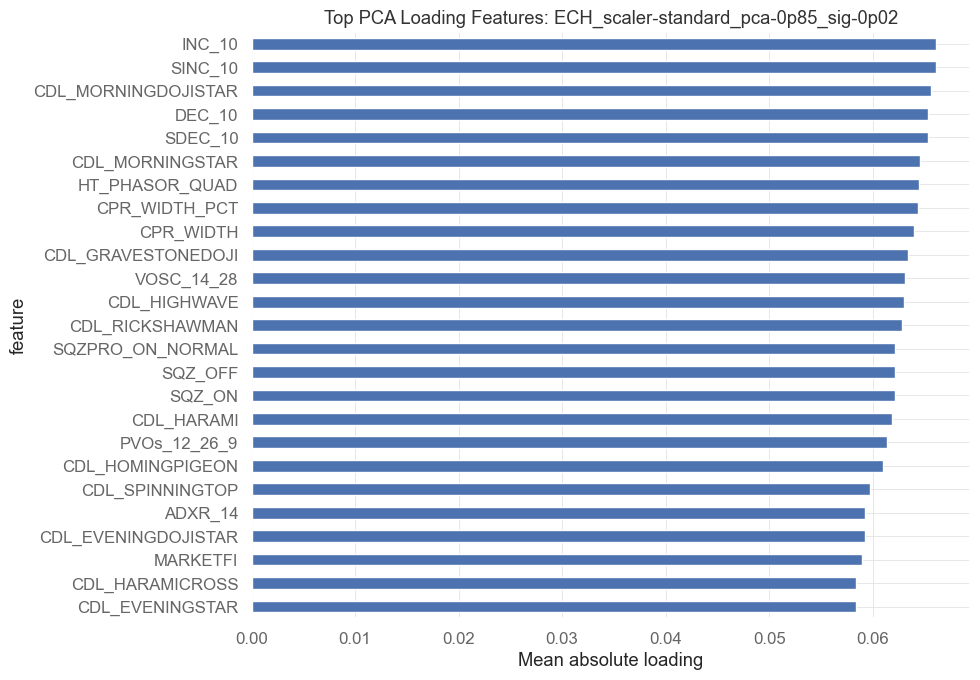

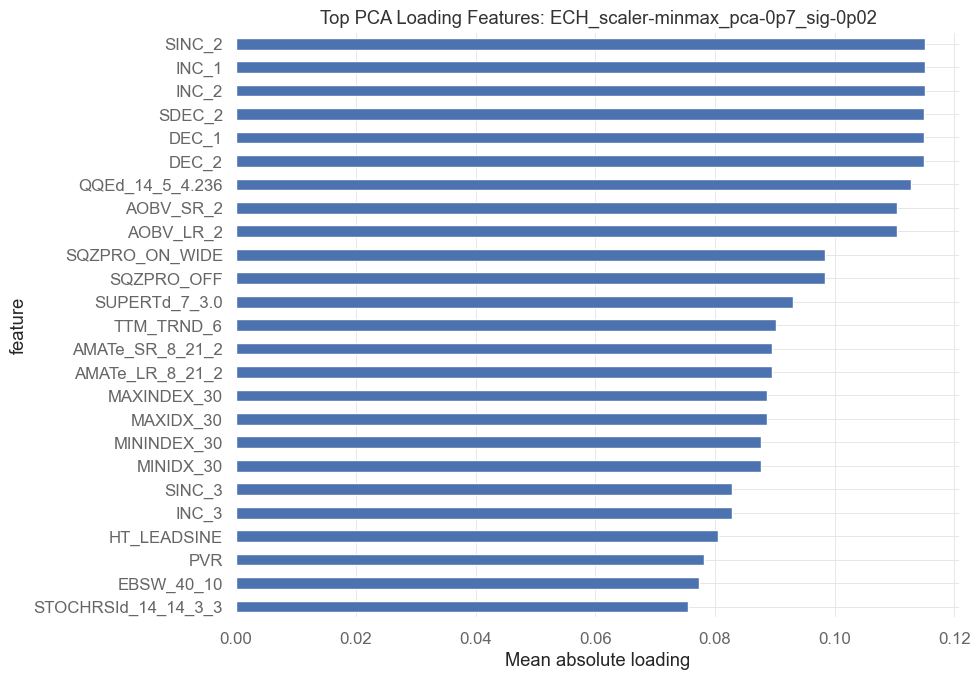

In [12]:
def plot_top_loading_features(run_id: str, top_n: int = 25):
    loading_summary = grid_artifacts[run_id]["loading_summary"]
    top = loading_summary.head(top_n).sort_values("mean_abs_loading")
    ax = top["mean_abs_loading"].plot(kind="barh", figsize=(10, max(4, top_n * 0.28)), title=f"Top PCA Loading Features: {run_id}")
    ax.set_xlabel("Mean absolute loading")
    plt.tight_layout()
    plt.show()


best_by_scaler = metrics_df.sort_values("net_sharpe", ascending=False).groupby("pca_scaler").head(1)
display(best_by_scaler[leaderboard_cols].round(4))

for run_id in best_by_scaler["run_id"]:
    plot_top_loading_features(run_id, top_n=25)

,standard_mean_abs_loading,standard_mean_rank,standard_appearances,minmax_mean_abs_loading,minmax_mean_rank,minmax_appearances,abs_loading_delta_minmax_minus_standard,combined_abs_loading
feature,,,,,,,,
THERMOs_20_2_0.5,0.05176,138.82151,10673,0.12796,98.35024,4711,0.07620,0.17972
AOBV_LR_2,0.04873,122.48684,10673,0.11372,59.56570,4711,0.06499,0.16246
AOBV_SR_2,0.04873,122.49517,10673,0.11372,59.56761,4711,0.06499,0.16246
SQZPRO_ON_WIDE,0.05808,124.43971,10673,0.09856,89.31076,4711,0.04048,0.15664
SQZPRO_OFF,0.05808,124.42762,10673,0.09856,89.30928,4711,0.04048,0.15664
STC_10_12_26_0.5,0.05214,129.67357,10673,0.10316,66.10868,4711,0.05103,0.15530
HT_TRENDMODE,0.03826,152.66045,10673,0.11405,79.45192,4711,0.07580,0.15231
INC_3,0.04516,131.84400,10673,0.10212,72.61431,4711,0.05696,0.14728
SINC_3,0.04516,131.85421,10673,0.10212,72.60348,4711,0.05696,0.14728


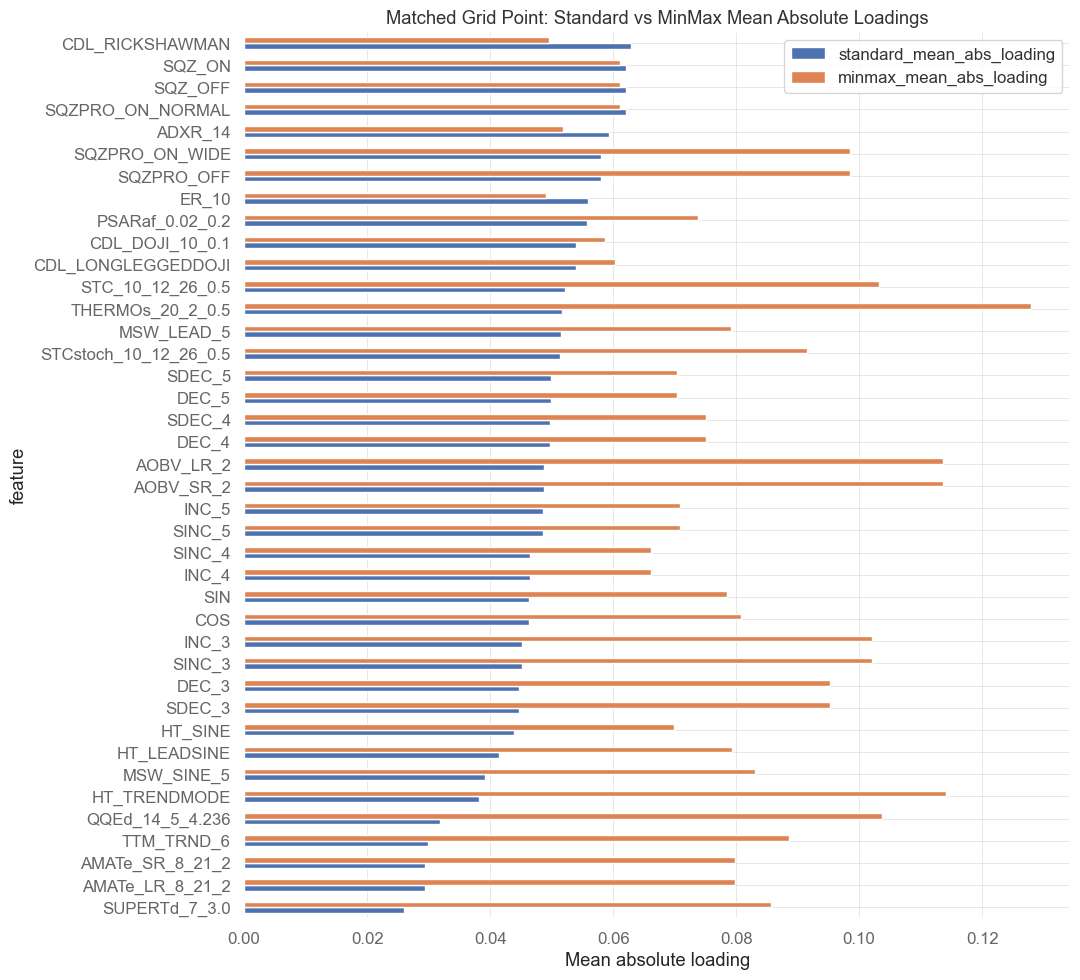

In [13]:
def compare_loading_summaries(standard_run_id: str, minmax_run_id: str, top_n: int = 30) -> pd.DataFrame:
    standard = grid_artifacts[standard_run_id]["loading_summary"][["mean_abs_loading", "mean_rank", "appearances"]].add_prefix("standard_")
    minmax = grid_artifacts[minmax_run_id]["loading_summary"][["mean_abs_loading", "mean_rank", "appearances"]].add_prefix("minmax_")
    comparison = standard.join(minmax, how="outer").fillna(0)
    comparison["abs_loading_delta_minmax_minus_standard"] = comparison["minmax_mean_abs_loading"] - comparison["standard_mean_abs_loading"]
    comparison["combined_abs_loading"] = comparison["minmax_mean_abs_loading"] + comparison["standard_mean_abs_loading"]
    return comparison.sort_values("combined_abs_loading", ascending=False).head(top_n)


# Compare matched runs for the best Standard grid point.
best_standard = metrics_df[metrics_df["pca_scaler"] == "standard"].sort_values("net_sharpe", ascending=False).iloc[0]
matched_minmax_id = make_run_id(SYMBOL, "minmax", best_standard["pca_n_components"], best_standard["signal_threshold"])

loading_comparison = compare_loading_summaries(best_standard["run_id"], matched_minmax_id, top_n=40)
display(loading_comparison.round(5))

ax = loading_comparison[["standard_mean_abs_loading", "minmax_mean_abs_loading"]].sort_values("standard_mean_abs_loading").plot(
    kind="barh",
    figsize=(11, 10),
    title="Matched Grid Point: Standard vs MinMax Mean Absolute Loadings",
)
ax.set_xlabel("Mean absolute loading")
plt.tight_layout()
plt.show()

## 11. Loading Stability Through Time

This looks for features whose PCA loading importance is stable versus features that appear strongly only intermittently. Lower loading standard deviation is generally easier to interpret, but high stability does not by itself imply predictive value.

In [14]:
for run_id in best_by_scaler["run_id"]:
    stability = grid_artifacts[run_id]["loading_stability"]
    pc1 = stability[stability["component"] == "PC1"].copy()
    pc1["stability_ratio"] = pc1["std_abs_loading"] / pc1["mean_abs_loading"].replace(0, np.nan)
    print(run_id)
    display(pc1.sort_values("mean_abs_loading", ascending=False).head(25).round(5))

ECH_scaler-standard_pca-0p85_sig-0p02


,component,feature,mean_abs_loading,std_abs_loading,mean_signed_loading,std_signed_loading,mean_rank,observations,stability_ratio
134,PC1,DEMA_10,0.08277,0.00007,0.08277,0.00007,1.000,250,0.00084
155,PC1,FWMA_10,0.08274,0.00008,0.08274,0.00008,2.344,250,0.00096
349,PC1,SSF_10_2,0.08273,0.00008,0.08273,0.00008,3.396,250,0.00093
427,PC1,ZL_EMA_10,0.08272,0.00007,0.08272,0.00007,3.940,250,0.00082
193,PC1,JMA_7_0,0.08271,0.00007,0.08271,0.00007,6.212,250,0.00089
292,PC1,RAINBOW_2,0.08271,0.00007,0.08271,0.00007,7.028,250,0.00087
2,PC1,ABER_XG_5_15,0.08271,0.00009,0.08271,0.00009,7.456,250,0.00104
368,PC1,TEMA_10,0.08271,0.00006,0.08271,0.00006,8.100,250,0.00072
158,PC1,HA_low,0.08270,0.00007,0.08270,0.00007,8.660,250,0.00083
293,PC1,RAINBOW_3,0.08270,0.00008,0.08270,0.00008,10.180,250,0.00094


ECH_scaler-minmax_pca-0p7_sig-0p02


,component,feature,mean_abs_loading,std_abs_loading,mean_signed_loading,std_signed_loading,mean_rank,observations,stability_ratio
413,PC1,VIDYA_14,0.09728,0.00026,0.09728,0.00026,1.460,250,0.00269
423,PC1,WAD,0.09698,0.00246,0.09698,0.00246,2.512,250,0.02534
249,PC1,MMAR_35,0.09643,0.00024,0.09643,0.00024,2.552,250,0.00248
248,PC1,MMAR_30,0.09527,0.00021,0.09527,0.00021,3.760,250,0.00222
247,PC1,MMAR_25,0.09353,0.00018,0.09353,0.00018,4.924,250,0.00191
198,PC1,KCUe_20_2,0.09327,0.00012,0.09327,0.00012,5.896,250,0.00131
120,PC1,DCU_20_20,0.09278,0.00016,0.09278,0.00016,6.940,250,0.00170
379,PC1,TOS_STDEVALL_126_U_1,0.09220,0.00036,0.09220,0.00036,8.260,250,0.00394
150,PC1,FAMA_0.5_0.05,0.09193,0.00018,0.09193,0.00018,8.700,250,0.00199
232,PC1,MAX_30,0.09164,0.00021,0.09164,0.00021,9.996,250,0.00228


## 12. Equity Curves for Scaler Winners

This compares the best StandardScaler run and the best MinMaxScaler run by net Sharpe.

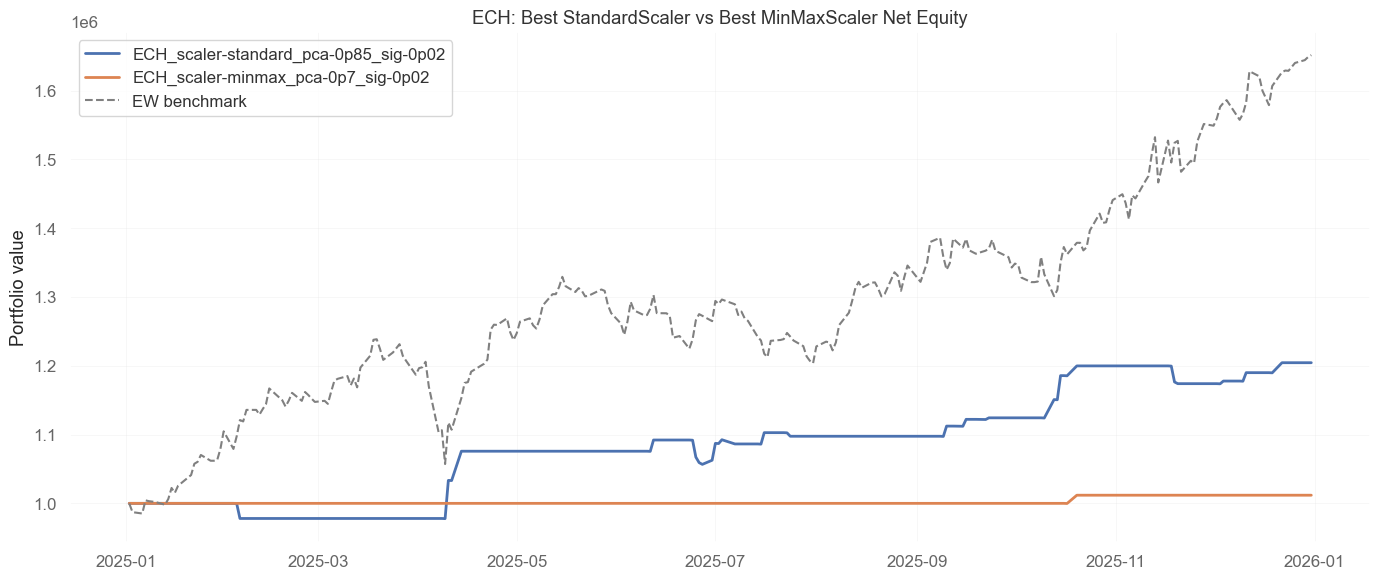

In [15]:
fig, ax = plt.subplots(figsize=(14, 6))

for _, row in best_by_scaler.iterrows():
    run_id = row["run_id"]
    stats = grid_artifacts[run_id]["stats"]
    ax.plot(stats.index, stats["net_equity"], label=run_id, linewidth=2)

benchmark_stats = grid_artifacts[best_by_scaler.iloc[0]["run_id"]]["stats"]
ax.plot(benchmark_stats.index, INITIAL_CAPITAL * benchmark_stats["cum_benchmark"], color="gray", linestyle="--", label="EW benchmark")

ax.set_title(f"{SYMBOL}: Best StandardScaler vs Best MinMaxScaler Net Equity")
ax.set_ylabel("Portfolio value")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Notes on Component Scores and Convergence

This notebook captures the artifacts currently generated by `ML_predictor_PCA.py`: weights, weight diagnostics, portfolio stats, PCA loadings, explained variance, and retained component counts.

Two potentially useful diagnostics are not currently generated by the strategy itself:

- The actual PCA component score vector passed to the MLP for each prediction date.
- Per-run MLP convergence-warning counts, because the strategy intentionally suppresses `ConvergenceWarning` during rolling fits.

If the scaler comparison points to an interesting difference, the next useful instrumentation would be to add optional recording of `pca.transform(X_predict)` and convergence state per prediction date.

## 14. Interpretation Checklist

After the grid completes, compare the scalers on:

- Net Sharpe and net return, not only gross return.
- Max drawdown and whether drawdown improvement costs too much return.
- Turnover and total fees.
- Active/long/short/flat day distribution.
- Prediction agreement between scalers at matched grid points.
- Retained component count under each variance threshold.
- Explained variance spectrum, especially PC1 dominance.
- Top loading features and whether they change materially by scaler.
- Loading stability through time.
- Whether performance is robust across nearby grid points or concentrated in one fragile case.

## 15. Scaler Conclusion

For the current saved `ECH` grid, `standard` is the better-performing PCA scaler overall.

The strongest single `standard` run is `ECH_scaler-standard_pca-0p85_sig-0p02`, with net Sharpe around `1.96`, net return around `20.45%`, and max drawdown around `-3.24%`. The strongest `minmax` run is `ECH_scaler-minmax_pca-0p7_sig-0p02`, with net Sharpe around `0.99`, net return around `1.18%`, and very low drawdown because it is active only about `0.4%` of days.

Across matched parameter combinations, `standard` also wins more often: it has higher net Sharpe in 14 of 19 comparable cases, higher net return in 14 of 20 cases, and better max drawdown in 14 of 20 cases. The leaderboard concentration points the same way: 4 of the top 5, 8 of the top 10, and 11 of the top 15 Sharpe-ranked runs use `standard`.

The main caveat is that this is not universal proof that `standard` will always beat `minmax`. It is one symbol, one date window, one grid, and one model configuration. Still, it is enough evidence to use `standard` as the preferred scaler for the next `ECH` combined-strategy exploration.

## APP 1. Run combined strategy of 3 best performers

Take the 3 best performers – runs with indices `9`, `13`, and `14` – and do a combine strategy with `position_size` `0.34`, `0.33` and `0.33` respectively.

Combining the three strategies aims at smoothing the bumps in the evolution, which in turn shoudl improve the Sharpe ratio over longer periods and be more reliable over longer periods.

#### Run it for the dates `"2025-01-01"` to `"2026-01-01"`:

🧠 Predicting 2025-12-31 |  250/250 |  last: 4.58s |  elapsed: 13m 1.4ss
✅ Prediction complete. Took 13m 5.7s


📊 --- QUICK PORTFOLIO RESULTS: ECH ML Walk Forward ---
   Frictionless Return:     11.76%
   Net Strategy Return:     10.51%  (EW Benchmark: 65.17%)
   Max Drawdown:            -2.38%
   Win Rate (Gross Bars):   24.5%   (EW Benchmark: 54.6%)
   Loss Rate (Gross Bars):  18.5%   (EW Benchmark: 43.0%)
   Zero Rate (Gross Bars):  57.0%    (EW Benchmark: 2.4%)
   Sharpe Ratio (Net):      1.90    (EW Benchmark: 2.39)
   Sortino/√2 (Net):        2.34    (EW Benchmark: 2.67)
   Total Fees Paid:         $12,508.91
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/research/Tearsheets/ECH_ML_Walk_Forward_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


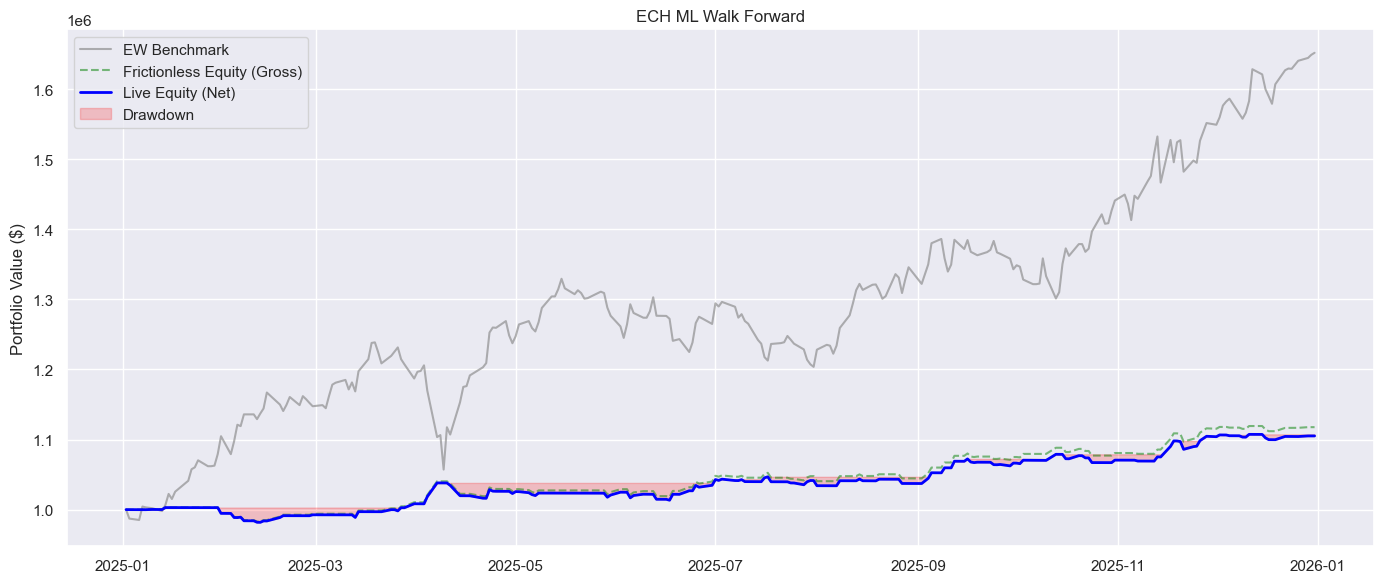

🧠 Predicting 2025-12-31 |  250/250 |  last: 6.26s |  elapsed: 17m 5.2ss
✅ Prediction complete. Took 17m 11.1s


📊 --- QUICK PORTFOLIO RESULTS: ECH ML Walk Forward ---
   Frictionless Return:     8.58%
   Net Strategy Return:     7.33%  (EW Benchmark: 65.17%)
   Max Drawdown:            -3.03%
   Win Rate (Gross Bars):   23.3%   (EW Benchmark: 54.6%)
   Loss Rate (Gross Bars):  22.1%   (EW Benchmark: 43.0%)
   Zero Rate (Gross Bars):  54.6%    (EW Benchmark: 2.4%)
   Sharpe Ratio (Net):      1.40    (EW Benchmark: 2.39)
   Sortino/√2 (Net):        1.81    (EW Benchmark: 2.67)
   Total Fees Paid:         $12,569.39
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/research/Tearsheets/ECH_ML_Walk_Forward_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


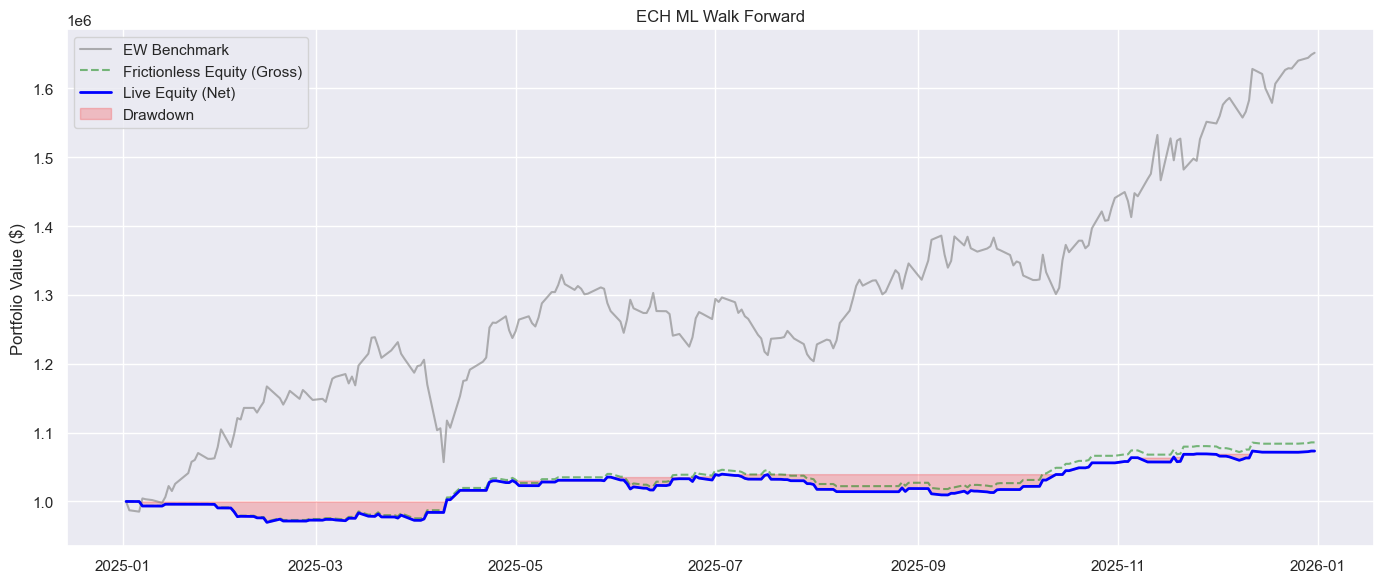

🧠 Predicting 2025-12-31 |  250/250 |  last: 5.06s |  elapsed: 13m 10.2s
✅ Prediction complete. Took 13m 15.2s


📊 --- QUICK PORTFOLIO RESULTS: ECH ML Walk Forward ---
   Frictionless Return:     6.75%
   Net Strategy Return:     6.42%  (EW Benchmark: 65.17%)
   Max Drawdown:            -1.07%
   Win Rate (Gross Bars):   6.4%   (EW Benchmark: 54.6%)
   Loss Rate (Gross Bars):  3.2%   (EW Benchmark: 43.0%)
   Zero Rate (Gross Bars):  90.4%    (EW Benchmark: 2.4%)
   Sharpe Ratio (Net):      1.96    (EW Benchmark: 2.39)
   Sortino/√2 (Net):        3.53    (EW Benchmark: 2.67)
   Total Fees Paid:         $3,255.04
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/research/Tearsheets/ECH_ML_Walk_Forward_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


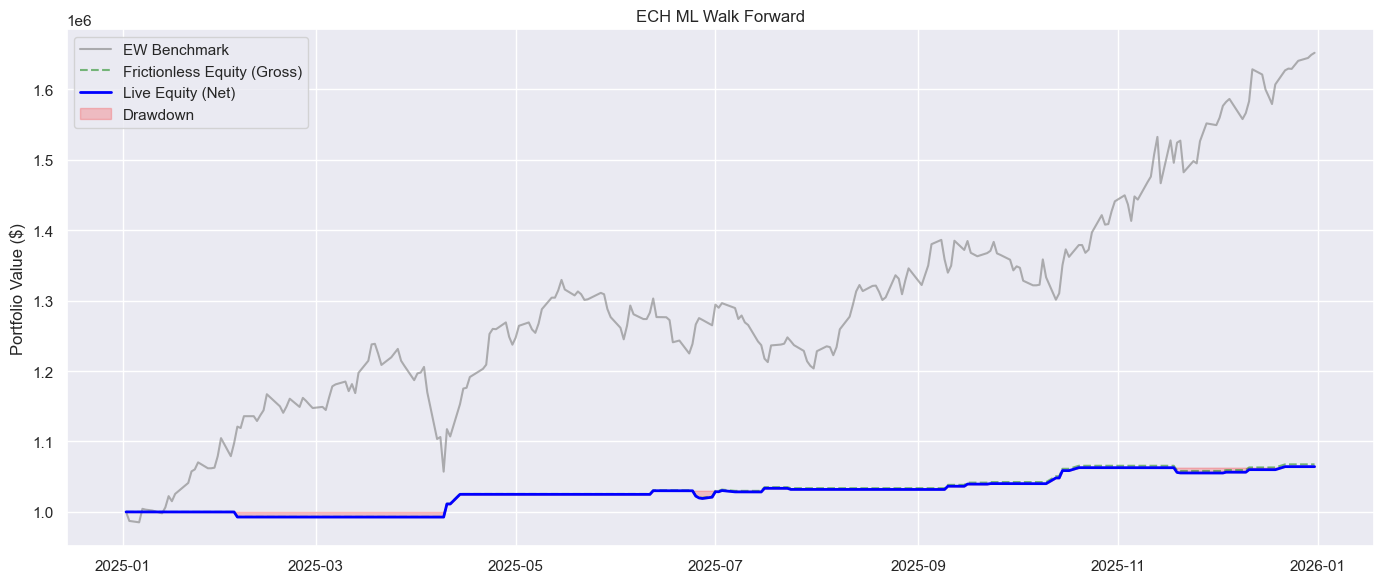


📊 --- QUICK PORTFOLIO RESULTS: ECH Combined PCA Strategy: Runs 9, 13, 14 ---
   Frictionless Return:     29.42%
   Net Strategy Return:     27.21%  (EW Benchmark: 65.17%)
   Max Drawdown:            -5.24%
   Win Rate (Gross Bars):   34.5%   (EW Benchmark: 54.6%)
   Loss Rate (Gross Bars):  29.3%   (EW Benchmark: 43.0%)
   Zero Rate (Gross Bars):  36.1%    (EW Benchmark: 2.4%)
   Sharpe Ratio (Net):      2.67    (EW Benchmark: 2.39)
   Sortino/√2 (Net):        4.07    (EW Benchmark: 2.67)
   Total Fees Paid:         $22,109.53
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/research/Tearsheets/ECH_Combined_PCA_Strategy:_Runs_9,_13,_14_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


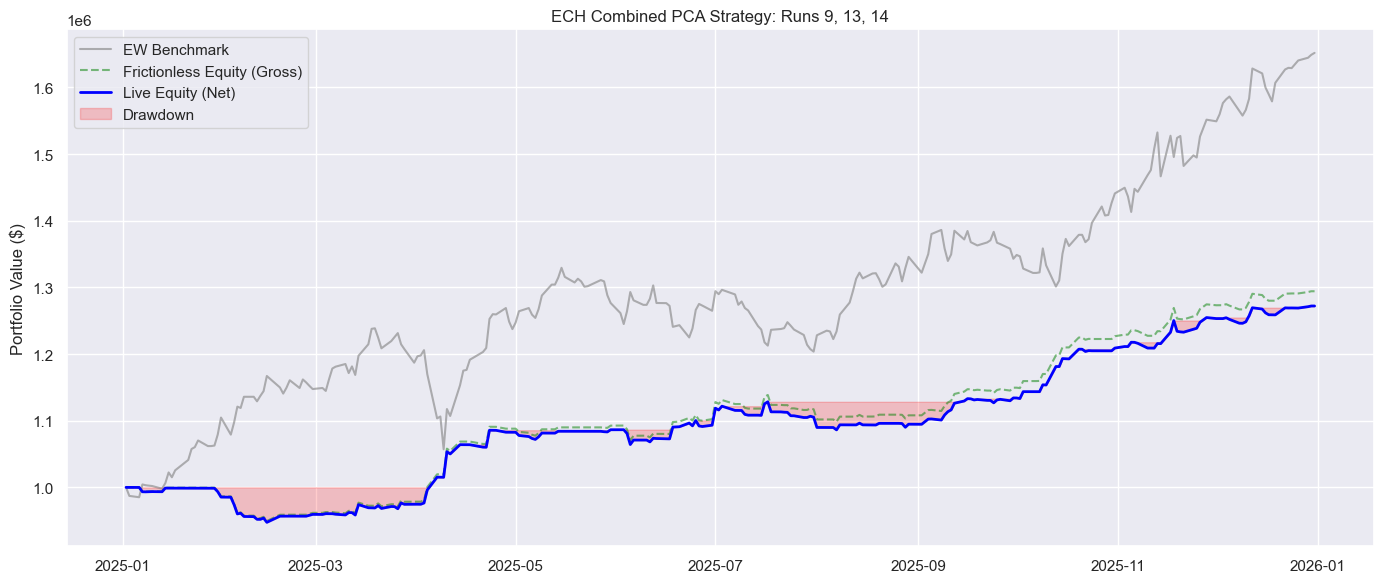

,ECH_scaler-standard_pca-0p8_sig-0p01,ECH_scaler-standard_pca-0p85_sig-0p01,ECH_scaler-standard_pca-0p85_sig-0p02
Timestamp,,,
2025-01-02,0.00,0.00,0.0
2025-01-03,0.00,-0.33,0.0
2025-01-06,0.00,0.00,0.0
2025-01-07,-0.34,0.00,0.0
2025-01-08,0.00,0.00,0.0


,ECH
Timestamp,
2025-01-02,0.00
2025-01-03,-0.33
2025-01-06,0.00
2025-01-07,-0.34
2025-01-08,0.00


,gross_returns,gross_equity,total_costs_usd,cumulative_costs,net_equity,net_returns,cum_benchmark
Timestamp,,,,,,,
2025-12-24,0.000168,1.290883e+06,162.569916,21757.263527,1.269125e+06,0.000043,1.628892
2025-12-26,0.000000,1.290883e+06,162.106489,21919.370016,1.268963e+06,-0.000128,1.640343
2025-12-29,0.001670,1.293039e+06,96.501041,22015.871056,1.271023e+06,0.001623,1.644432
2025-12-30,0.000889,1.294188e+06,93.658338,22109.529394,1.272079e+06,0.000831,1.648862
2025-12-31,0.000000,1.294188e+06,0.000000,22109.529394,1.272079e+06,0.000000,1.651731


In [15]:
from src.vector_backtester_Mateo import PortfolioVectorEngine

SYMBOL = "ECH"
COMMON_PARAMS["symbol"] = SYMBOL

combined_specs = [
    {
        "run_number": 9,
        "pca_scaler": "standard",
        "pca_n_components": 0.8,
        "signal_threshold": 0.01,
        "position_size": 0.34,
    },
    {
        "run_number": 13,
        "pca_scaler": "standard",
        "pca_n_components": 0.85,
        "signal_threshold": 0.01,
        "position_size": 0.33,
    },
    {
        "run_number": 14,
        "pca_scaler": "standard",
        "pca_n_components": 0.85,
        "signal_threshold": 0.02,
        "position_size": 0.33,
    },
]

combined_artifacts = {}
combined_weights_parts = []

for spec in combined_specs:
    run_id = make_run_id(
        SYMBOL,
        spec["pca_scaler"],
        spec["pca_n_components"],
        spec["signal_threshold"],
    )

    artifacts = run_single_case_PCA(
        symbol=SYMBOL,
        asset_class=ASSET_CLASS,
        start_date=COMMON_PARAMS["start_date"],
        # start_date="2025-12-01",
        end_date=COMMON_PARAMS["end_date"],
        # end_date="2026-01-01",
        signal_threshold=spec["signal_threshold"],
        pca_n_components=spec["pca_n_components"],
        pca_scaler=spec["pca_scaler"],
        training_years=COMMON_PARAMS["training_years"],
        sharpe_filter_enabled=COMMON_PARAMS["sharpe_filter_enabled"],
        feature_diagnostics_enabled=COMMON_PARAMS["feature_diagnostics_enabled"],
        feature_diagnostics_top_n=COMMON_PARAMS["feature_diagnostics_top_n"],
        position_size=spec["position_size"],
        initial_capital=INITIAL_CAPITAL,
        max_iter=COMMON_PARAMS["max_iter"],
        execution_delay=EXECUTION_DELAY,
        verbose=COMMON_PARAMS["verbose"],
        show_progress=True,
        show_tearsheet=True,
        return_artifacts=True,
    )

    artifacts["run_id"] = run_id
    artifacts["combined_weight"] = spec["position_size"]
    combined_artifacts[run_id] = artifacts

    combined_weights_parts.append(
        artifacts["weights"].rename(columns={SYMBOL: run_id})
    )

combined_component_weights = pd.concat(combined_weights_parts, axis=1).fillna(0)
combined_weights = pd.DataFrame(
    {SYMBOL: combined_component_weights.sum(axis=1)},
    index=combined_component_weights.index,
)

combined_prices = (
    next(iter(combined_artifacts.values()))["dataset"][["Open"]]
    .rename(columns={"Open": SYMBOL})
    .loc[combined_weights.index]
)

combined_engine = PortfolioVectorEngine(
    prices=combined_prices,
    signals=combined_weights,
    asset_class=ASSET_CLASS,
    initial_capital=INITIAL_CAPITAL,
    execution_delay=EXECUTION_DELAY,
)

combined_stats = combined_engine.run()
combined_engine.tearsheet("ECH Combined PCA Strategy: Runs 9, 13, 14")

combined_strategy_artifacts = {
    "symbol": SYMBOL,
    "specs": combined_specs,
    "component_artifacts": combined_artifacts,
    "component_weights": combined_component_weights,
    "weights": combined_weights,
    "prices": combined_prices,
    "engine": combined_engine,
    "stats": combined_stats,
}

display(combined_component_weights.head())
display(combined_weights.head())
display(combined_stats.tail())

#### Run it for the dates `"2026-01-01"` to `"2026-07-01"`:

🧠 Predicting 2026-06-30 |  123/123 |  last: 4.18s |  elapsed: 6m 19.1s
✅ Prediction complete. Took 6m 23.5s


📊 --- QUICK PORTFOLIO RESULTS: ECH ML Walk Forward ---
   Frictionless Return:     -4.94%
   Net Strategy Return:     -5.54%  (EW Benchmark: -1.03%)
   Max Drawdown:            -9.84%
   Win Rate (Gross Bars):   29.5%   (EW Benchmark: 50.8%)
   Loss Rate (Gross Bars):  31.1%   (EW Benchmark: 49.2%)
   Zero Rate (Gross Bars):  39.3%    (EW Benchmark: 0.0%)
   Sharpe Ratio (Net):      -1.24    (EW Benchmark: 0.12)
   Sortino/√2 (Net):        -1.10    (EW Benchmark: 0.12)
   Total Fees Paid:         $6,018.02
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/research/Tearsheets/ECH_ML_Walk_Forward_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


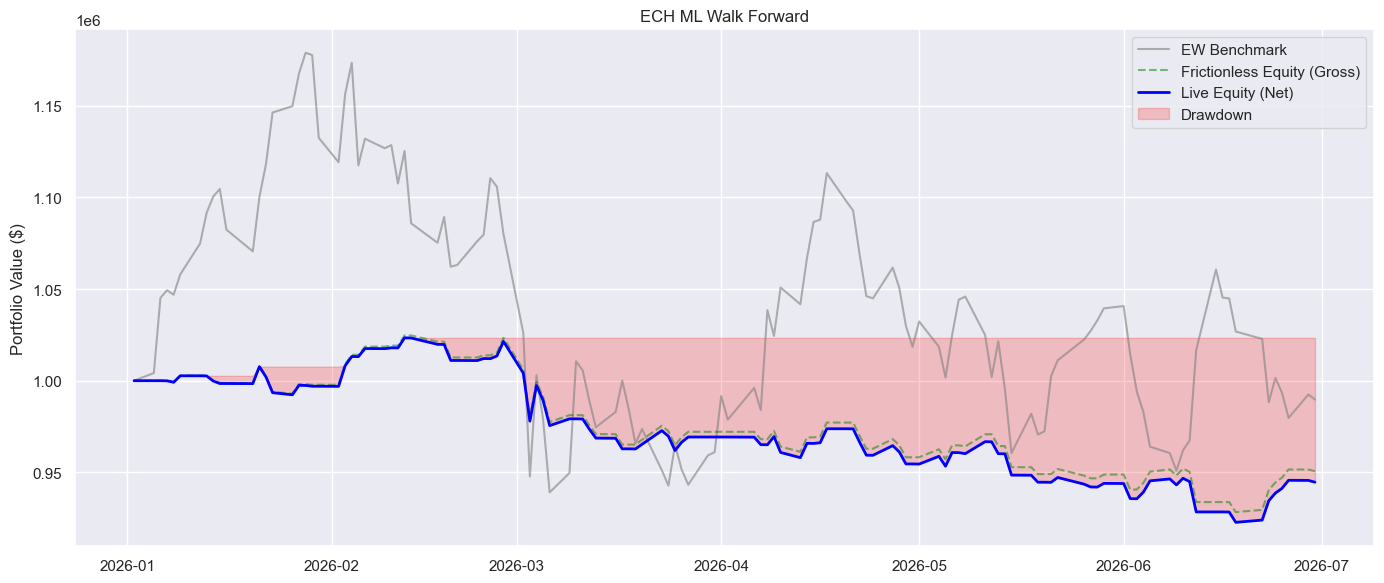

🧠 Predicting 2026-06-30 |  123/123 |  last: 6.05s |  elapsed: 9m 34.6s
✅ Prediction complete. Took 9m 40.7s


📊 --- QUICK PORTFOLIO RESULTS: ECH ML Walk Forward ---
   Frictionless Return:     18.65%
   Net Strategy Return:     17.93%  (EW Benchmark: -1.03%)
   Max Drawdown:            -1.66%
   Win Rate (Gross Bars):   39.3%   (EW Benchmark: 50.8%)
   Loss Rate (Gross Bars):  25.4%   (EW Benchmark: 49.2%)
   Zero Rate (Gross Bars):  35.2%    (EW Benchmark: 0.0%)
   Sharpe Ratio (Net):      3.74    (EW Benchmark: 0.12)
   Sortino/√2 (Net):        5.29    (EW Benchmark: 0.12)
   Total Fees Paid:         $7,179.44
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/research/Tearsheets/ECH_ML_Walk_Forward_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


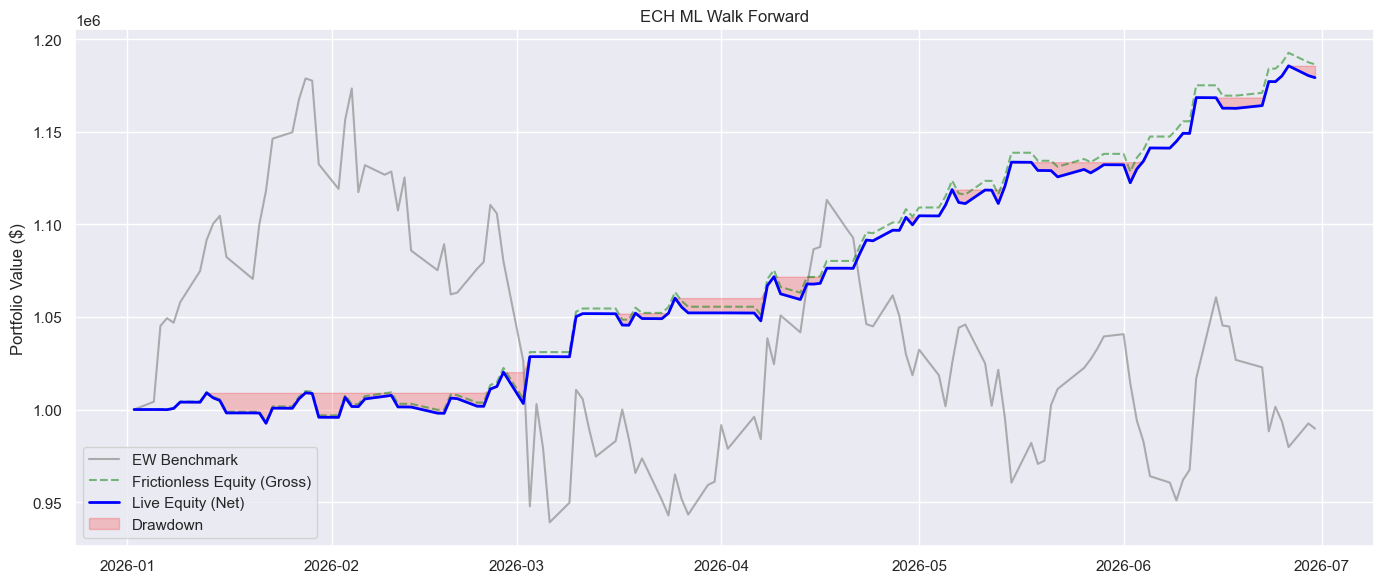

🧠 Predicting 2026-06-30 |  123/123 |  last: 4.47s |  elapsed: 7m 1.2ss
✅ Prediction complete. Took 7m 5.6s


📊 --- QUICK PORTFOLIO RESULTS: ECH ML Walk Forward ---
   Frictionless Return:     -1.57%
   Net Strategy Return:     -1.88%  (EW Benchmark: -1.03%)
   Max Drawdown:            -4.75%
   Win Rate (Gross Bars):   12.3%   (EW Benchmark: 50.8%)
   Loss Rate (Gross Bars):  13.9%   (EW Benchmark: 49.2%)
   Zero Rate (Gross Bars):  73.8%    (EW Benchmark: 0.0%)
   Sharpe Ratio (Net):      -0.78    (EW Benchmark: 0.12)
   Sortino/√2 (Net):        -0.74    (EW Benchmark: 0.12)
   Total Fees Paid:         $3,108.64
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/research/Tearsheets/ECH_ML_Walk_Forward_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


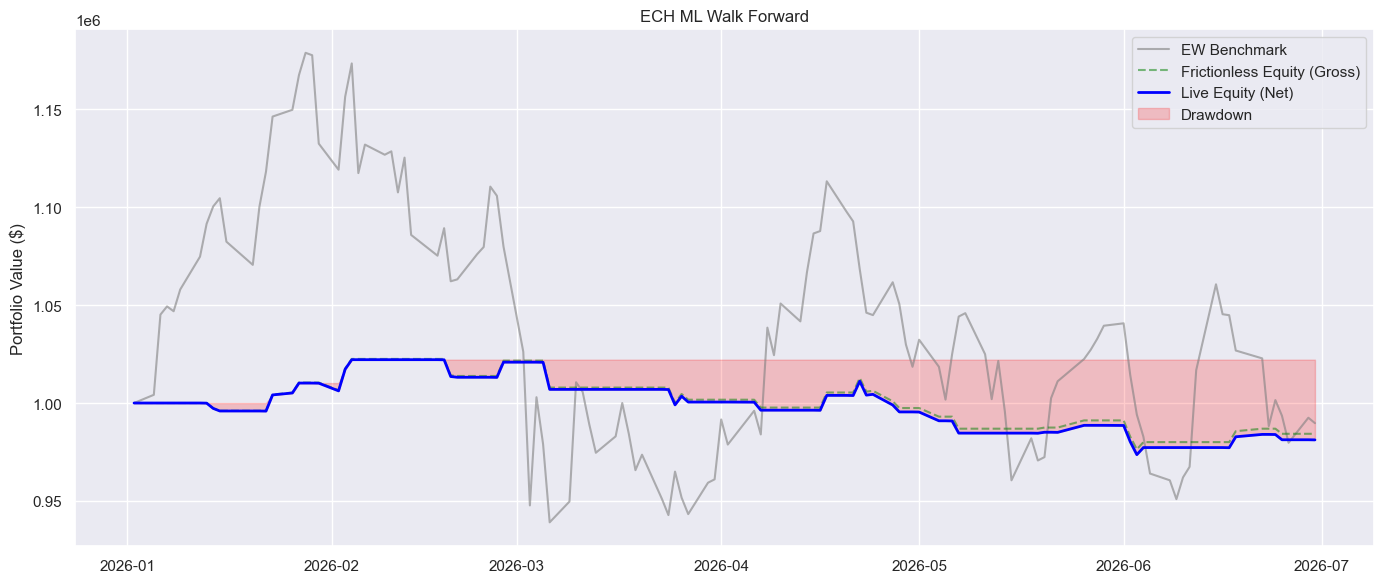


📊 --- QUICK PORTFOLIO RESULTS: ECH Combined PCA Strategy: Runs 9, 13, 14 ---
   Frictionless Return:     10.95%
   Net Strategy Return:     9.72%  (EW Benchmark: -1.03%)
   Max Drawdown:            -5.20%
   Win Rate (Gross Bars):   41.0%   (EW Benchmark: 50.8%)
   Loss Rate (Gross Bars):  37.7%   (EW Benchmark: 49.2%)
   Zero Rate (Gross Bars):  21.3%    (EW Benchmark: 0.0%)
   Sharpe Ratio (Net):      1.36    (EW Benchmark: 0.12)
   Sortino/√2 (Net):        1.47    (EW Benchmark: 0.12)
   Total Fees Paid:         $12,304.38
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/research/Tearsheets/ECH_Combined_PCA_Strategy:_Runs_9,_13,_14_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


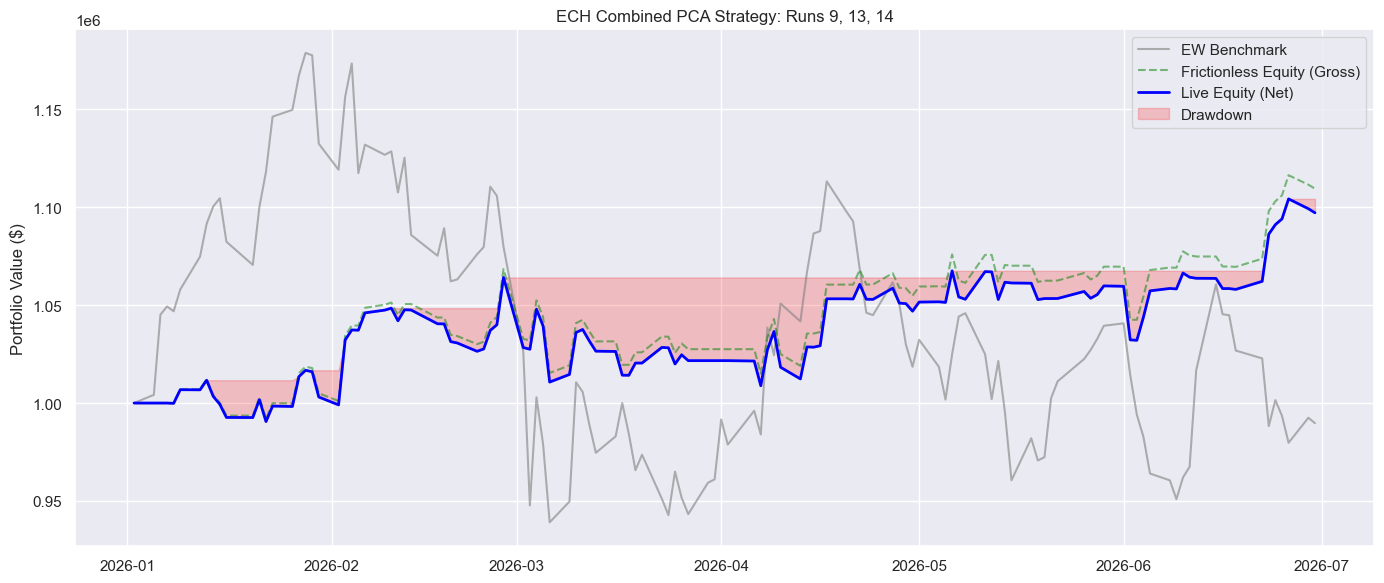

,ECH_scaler-standard_pca-0p8_sig-0p01,ECH_scaler-standard_pca-0p85_sig-0p01,ECH_scaler-standard_pca-0p85_sig-0p02
Timestamp,,,
2026-01-02,0.00,0.00,0.0
2026-01-05,0.00,0.00,0.0
2026-01-06,0.34,-0.33,0.0
2026-01-07,0.34,0.33,0.0
2026-01-08,0.00,0.00,0.0


,ECH
Timestamp,
2026-01-02,0.00
2026-01-05,0.00
2026-01-06,0.01
2026-01-07,0.67
2026-01-08,0.00


,gross_returns,gross_equity,total_costs_usd,cumulative_costs,net_equity,net_returns,cum_benchmark
Timestamp,,,,,,,
2026-06-24,0.004571,1.103113e+06,165.426652,11941.448102,1.091172e+06,0.004469,1.001498
2026-06-25,0.002723,1.106118e+06,81.302586,12022.750688,1.094095e+06,0.002679,0.993476
2026-06-26,0.009298,1.116403e+06,68.696613,12091.447302,1.104311e+06,0.009338,0.979689
2026-06-29,-0.004307,1.111595e+06,210.636086,12302.083388,1.099293e+06,-0.004544,0.992474
2026-06-30,-0.001862,1.109526e+06,2.297565,12304.380953,1.097221e+06,-0.001885,0.989716


In [13]:
from src.vector_backtester_Mateo import PortfolioVectorEngine

SYMBOL = "ECH"
COMMON_PARAMS["symbol"] = SYMBOL

combined_specs = [
    {
        "run_number": 9,
        "pca_scaler": "standard",
        "pca_n_components": 0.8,
        "signal_threshold": 0.01,
        "position_size": 0.34,
    },
    {
        "run_number": 13,
        "pca_scaler": "standard",
        "pca_n_components": 0.85,
        "signal_threshold": 0.01,
        "position_size": 0.33,
    },
    {
        "run_number": 14,
        "pca_scaler": "standard",
        "pca_n_components": 0.85,
        "signal_threshold": 0.02,
        "position_size": 0.33,
    },
]

combined_artifacts = {}
combined_weights_parts = []

for spec in combined_specs:
    run_id = make_run_id(
        SYMBOL,
        spec["pca_scaler"],
        spec["pca_n_components"],
        spec["signal_threshold"],
    )

    artifacts = run_single_case_PCA(
        symbol=SYMBOL,
        asset_class=ASSET_CLASS,
        # start_date=COMMON_PARAMS["start_date"],
        start_date="2026-01-01",
        # end_date=COMMON_PARAMS["end_date"],
        end_date="2026-07-01",
        signal_threshold=spec["signal_threshold"],
        pca_n_components=spec["pca_n_components"],
        pca_scaler=spec["pca_scaler"],
        training_years=COMMON_PARAMS["training_years"],
        sharpe_filter_enabled=COMMON_PARAMS["sharpe_filter_enabled"],
        feature_diagnostics_enabled=COMMON_PARAMS["feature_diagnostics_enabled"],
        feature_diagnostics_top_n=COMMON_PARAMS["feature_diagnostics_top_n"],
        position_size=spec["position_size"],
        initial_capital=INITIAL_CAPITAL,
        max_iter=COMMON_PARAMS["max_iter"],
        execution_delay=EXECUTION_DELAY,
        verbose=COMMON_PARAMS["verbose"],
        show_progress=True,
        show_tearsheet=True,
        return_artifacts=True,
    )

    artifacts["run_id"] = run_id
    artifacts["combined_weight"] = spec["position_size"]
    combined_artifacts[run_id] = artifacts

    combined_weights_parts.append(
        artifacts["weights"].rename(columns={SYMBOL: run_id})
    )

combined_component_weights = pd.concat(combined_weights_parts, axis=1).fillna(0)
combined_weights = pd.DataFrame(
    {SYMBOL: combined_component_weights.sum(axis=1)},
    index=combined_component_weights.index,
)

combined_prices = (
    next(iter(combined_artifacts.values()))["dataset"][["Open"]]
    .rename(columns={"Open": SYMBOL})
    .loc[combined_weights.index]
)

combined_engine = PortfolioVectorEngine(
    prices=combined_prices,
    signals=combined_weights,
    asset_class=ASSET_CLASS,
    initial_capital=INITIAL_CAPITAL,
    execution_delay=EXECUTION_DELAY,
)

combined_stats = combined_engine.run()
combined_engine.tearsheet("ECH Combined PCA Strategy: Runs 9, 13, 14")

combined_strategy_artifacts = {
    "symbol": SYMBOL,
    "specs": combined_specs,
    "component_artifacts": combined_artifacts,
    "component_weights": combined_component_weights,
    "weights": combined_weights,
    "prices": combined_prices,
    "engine": combined_engine,
    "stats": combined_stats,
}

display(combined_component_weights.head())
display(combined_weights.head())
display(combined_stats.tail())

#### Run it for the dates `"2024-01-01"` to `"2025-01-01"`:

🧠 Predicting 2024-12-31 |  252/252 |  last: 4.73s |  elapsed: 13m 57.2s
✅ Prediction complete. Took 14m 1.5s


📊 --- QUICK PORTFOLIO RESULTS: ECH ML Walk Forward ---
   Frictionless Return:     2.19%
   Net Strategy Return:     0.95%  (EW Benchmark: -7.55%)
   Max Drawdown:            -5.22%
   Win Rate (Gross Bars):   23.5%   (EW Benchmark: 49.4%)
   Loss Rate (Gross Bars):  20.7%   (EW Benchmark: 49.8%)
   Zero Rate (Gross Bars):  55.8%    (EW Benchmark: 0.8%)
   Sharpe Ratio (Net):      0.23    (EW Benchmark: -0.27)
   Sortino/√2 (Net):        0.23    (EW Benchmark: -0.26)
   Total Fees Paid:         $12,405.27
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/research/Tearsheets/ECH_ML_Walk_Forward_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


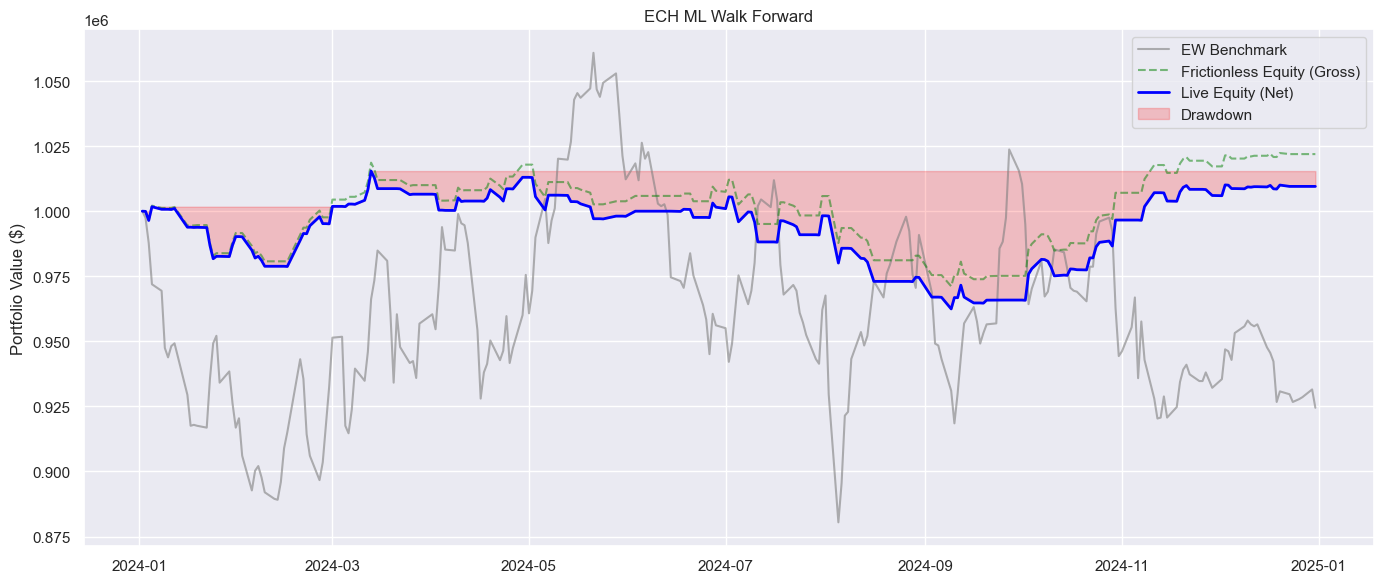

🧠 Predicting 2024-12-31 |  252/252 |  last: 6.47s |  elapsed: 18m 1.9ss
✅ Prediction complete. Took 18m 8.2s


📊 --- QUICK PORTFOLIO RESULTS: ECH ML Walk Forward ---
   Frictionless Return:     8.09%
   Net Strategy Return:     6.72%  (EW Benchmark: -7.55%)
   Max Drawdown:            -5.06%
   Win Rate (Gross Bars):   23.9%   (EW Benchmark: 49.4%)
   Loss Rate (Gross Bars):  17.1%   (EW Benchmark: 49.8%)
   Zero Rate (Gross Bars):  59.0%    (EW Benchmark: 0.8%)
   Sharpe Ratio (Net):      1.40    (EW Benchmark: -0.27)
   Sortino/√2 (Net):        1.57    (EW Benchmark: -0.26)
   Total Fees Paid:         $13,758.35
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/research/Tearsheets/ECH_ML_Walk_Forward_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


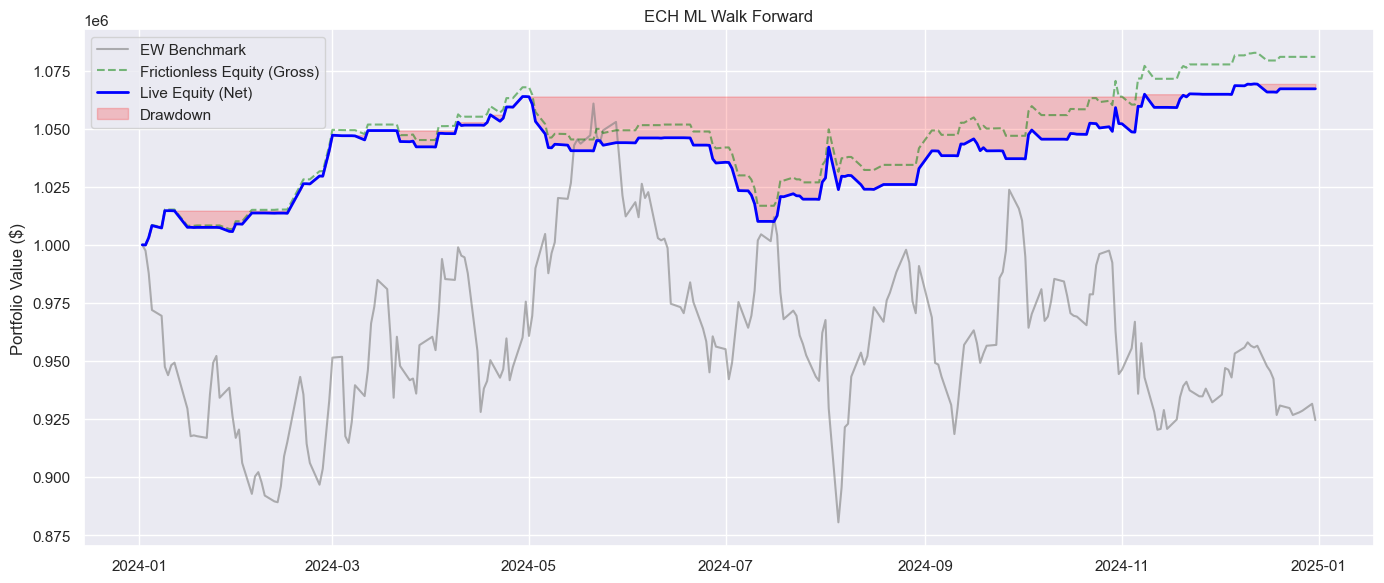

🧠 Predicting 2024-12-31 |  252/252 |  last: 5.16s |  elapsed: 14m 1.2ss
✅ Prediction complete. Took 14m 6.4s


📊 --- QUICK PORTFOLIO RESULTS: ECH ML Walk Forward ---
   Frictionless Return:     0.98%
   Net Strategy Return:     0.68%  (EW Benchmark: -7.55%)
   Max Drawdown:            -2.79%
   Win Rate (Gross Bars):   4.4%   (EW Benchmark: 49.4%)
   Loss Rate (Gross Bars):  4.4%   (EW Benchmark: 49.8%)
   Zero Rate (Gross Bars):  91.2%    (EW Benchmark: 0.8%)
   Sharpe Ratio (Net):      0.37    (EW Benchmark: -0.27)
   Sortino/√2 (Net):        0.42    (EW Benchmark: -0.26)
   Total Fees Paid:         $3,008.16
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/research/Tearsheets/ECH_ML_Walk_Forward_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


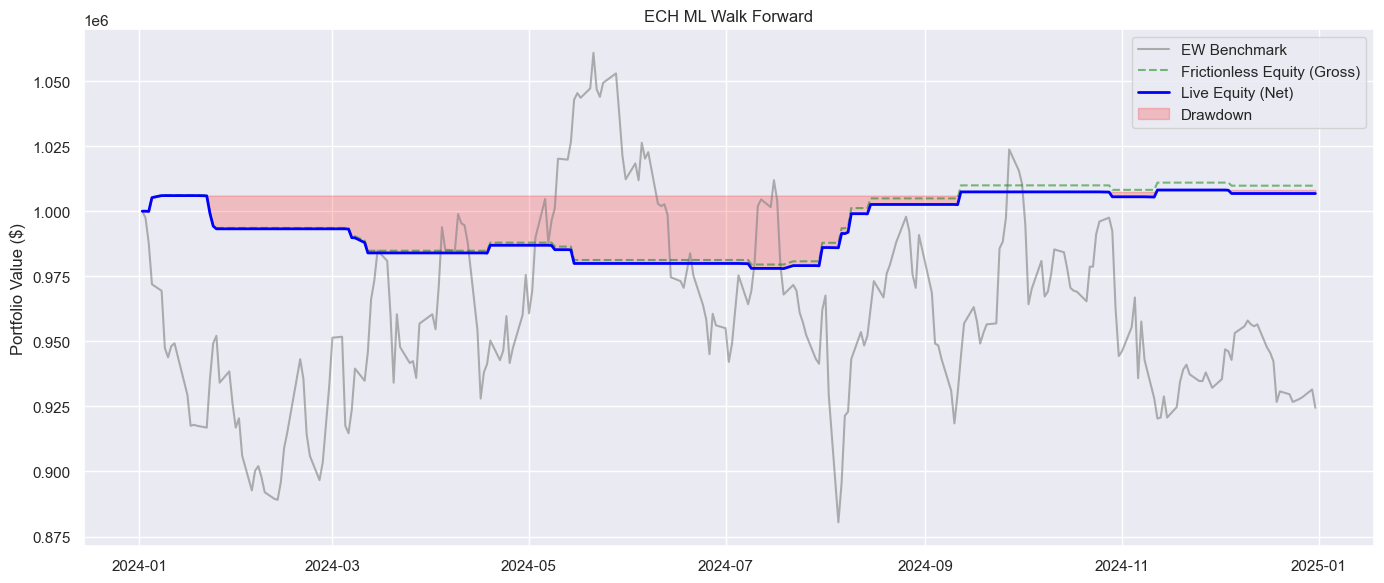


📊 --- QUICK PORTFOLIO RESULTS: ECH Combined PCA Strategy: Runs 9, 13, 14 ---
   Frictionless Return:     11.38%
   Net Strategy Return:     9.03%  (EW Benchmark: -7.55%)
   Max Drawdown:            -8.12%
   Win Rate (Gross Bars):   30.7%   (EW Benchmark: 49.4%)
   Loss Rate (Gross Bars):  28.7%   (EW Benchmark: 49.8%)
   Zero Rate (Gross Bars):  40.6%    (EW Benchmark: 0.8%)
   Sharpe Ratio (Net):      1.02    (EW Benchmark: -0.27)
   Sortino/√2 (Net):        1.11    (EW Benchmark: -0.26)
   Total Fees Paid:         $23,486.31
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/research/Tearsheets/ECH_Combined_PCA_Strategy:_Runs_9,_13,_14_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


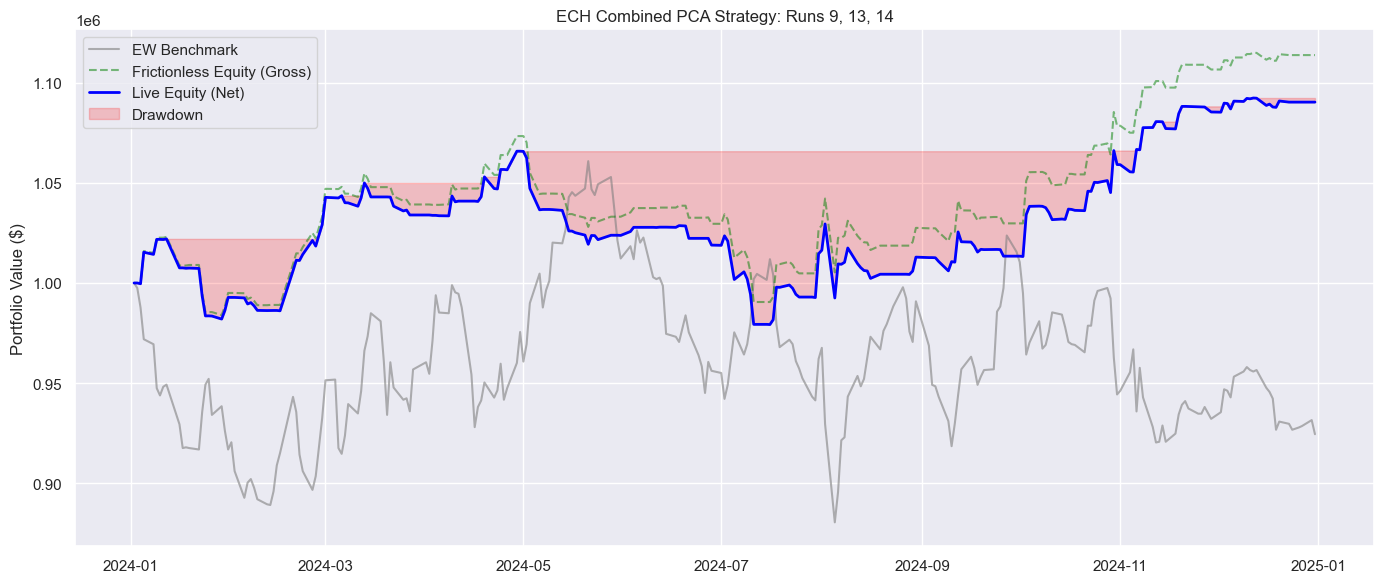

,ECH_scaler-standard_pca-0p8_sig-0p01,ECH_scaler-standard_pca-0p85_sig-0p01,ECH_scaler-standard_pca-0p85_sig-0p02
Timestamp,,,
2024-01-02,0.34,-0.33,0.00
2024-01-03,-0.34,-0.33,-0.33
2024-01-04,0.34,0.33,-0.33
2024-01-05,0.00,-0.33,0.00
2024-01-08,0.00,0.00,0.00


,ECH
Timestamp,
2024-01-02,0.01
2024-01-03,-1.00
2024-01-04,0.34
2024-01-05,-0.33
2024-01-08,0.00


,gross_returns,gross_equity,total_costs_usd,cumulative_costs,net_equity,net_returns,cum_benchmark
Timestamp,,,,,,,
2024-12-24,0.0,1.113810e+06,0.0,23486.308402,1.090324e+06,0.0,0.926707
2024-12-26,0.0,1.113810e+06,0.0,23486.308402,1.090324e+06,0.0,0.927818
2024-12-27,0.0,1.113810e+06,0.0,23486.308402,1.090324e+06,0.0,0.928559
2024-12-30,0.0,1.113810e+06,0.0,23486.308402,1.090324e+06,0.0,0.931522
2024-12-31,0.0,1.113810e+06,0.0,23486.308402,1.090324e+06,0.0,0.924485


In [14]:
from src.vector_backtester_Mateo import PortfolioVectorEngine

SYMBOL = "ECH"
COMMON_PARAMS["symbol"] = SYMBOL

combined_specs = [
    {
        "run_number": 9,
        "pca_scaler": "standard",
        "pca_n_components": 0.8,
        "signal_threshold": 0.01,
        "position_size": 0.34,
    },
    {
        "run_number": 13,
        "pca_scaler": "standard",
        "pca_n_components": 0.85,
        "signal_threshold": 0.01,
        "position_size": 0.33,
    },
    {
        "run_number": 14,
        "pca_scaler": "standard",
        "pca_n_components": 0.85,
        "signal_threshold": 0.02,
        "position_size": 0.33,
    },
]

combined_artifacts = {}
combined_weights_parts = []

for spec in combined_specs:
    run_id = make_run_id(
        SYMBOL,
        spec["pca_scaler"],
        spec["pca_n_components"],
        spec["signal_threshold"],
    )

    artifacts = run_single_case_PCA(
        symbol=SYMBOL,
        asset_class=ASSET_CLASS,
        # start_date=COMMON_PARAMS["start_date"],
        start_date="2024-01-01",
        # end_date=COMMON_PARAMS["end_date"],
        end_date="2025-01-01",
        signal_threshold=spec["signal_threshold"],
        pca_n_components=spec["pca_n_components"],
        pca_scaler=spec["pca_scaler"],
        training_years=COMMON_PARAMS["training_years"],
        sharpe_filter_enabled=COMMON_PARAMS["sharpe_filter_enabled"],
        feature_diagnostics_enabled=COMMON_PARAMS["feature_diagnostics_enabled"],
        feature_diagnostics_top_n=COMMON_PARAMS["feature_diagnostics_top_n"],
        position_size=spec["position_size"],
        initial_capital=INITIAL_CAPITAL,
        max_iter=COMMON_PARAMS["max_iter"],
        execution_delay=EXECUTION_DELAY,
        verbose=COMMON_PARAMS["verbose"],
        show_progress=True,
        show_tearsheet=True,
        return_artifacts=True,
    )

    artifacts["run_id"] = run_id
    artifacts["combined_weight"] = spec["position_size"]
    combined_artifacts[run_id] = artifacts

    combined_weights_parts.append(
        artifacts["weights"].rename(columns={SYMBOL: run_id})
    )

combined_component_weights = pd.concat(combined_weights_parts, axis=1).fillna(0)
combined_weights = pd.DataFrame(
    {SYMBOL: combined_component_weights.sum(axis=1)},
    index=combined_component_weights.index,
)

combined_prices = (
    next(iter(combined_artifacts.values()))["dataset"][["Open"]]
    .rename(columns={"Open": SYMBOL})
    .loc[combined_weights.index]
)

combined_engine = PortfolioVectorEngine(
    prices=combined_prices,
    signals=combined_weights,
    asset_class=ASSET_CLASS,
    initial_capital=INITIAL_CAPITAL,
    execution_delay=EXECUTION_DELAY,
)

combined_stats = combined_engine.run()
combined_engine.tearsheet("ECH Combined PCA Strategy: Runs 9, 13, 14")

combined_strategy_artifacts = {
    "symbol": SYMBOL,
    "specs": combined_specs,
    "component_artifacts": combined_artifacts,
    "component_weights": combined_component_weights,
    "weights": combined_weights,
    "prices": combined_prices,
    "engine": combined_engine,
    "stats": combined_stats,
}

display(combined_component_weights.head())
display(combined_weights.head())
display(combined_stats.tail())

#### Run it for the dates `"2024-01-01"` to `"2026-07-01"`:

🧠 Predicting 2026-06-30 |  625/625 |  last: 8.78s |  elapsed: 53m 25.3s
✅ Prediction complete. Took 53m 34.2s


📊 --- QUICK PORTFOLIO RESULTS: ECH ML Walk Forward ---
   Frictionless Return:     16.42%
   Net Strategy Return:     13.31%  (EW Benchmark: 52.28%)
   Max Drawdown:            -7.24%
   Win Rate (Gross Bars):   24.5%   (EW Benchmark: 51.9%)
   Loss Rate (Gross Bars):  21.8%   (EW Benchmark: 46.8%)
   Zero Rate (Gross Bars):  53.7%    (EW Benchmark: 1.3%)
   Sharpe Ratio (Net):      0.84    (EW Benchmark: 0.81)
   Sortino/√2 (Net):        0.92    (EW Benchmark: 0.83)
   Total Fees Paid:         $31,149.06
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/research/Tearsheets/ECH_ML_Walk_Forward_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


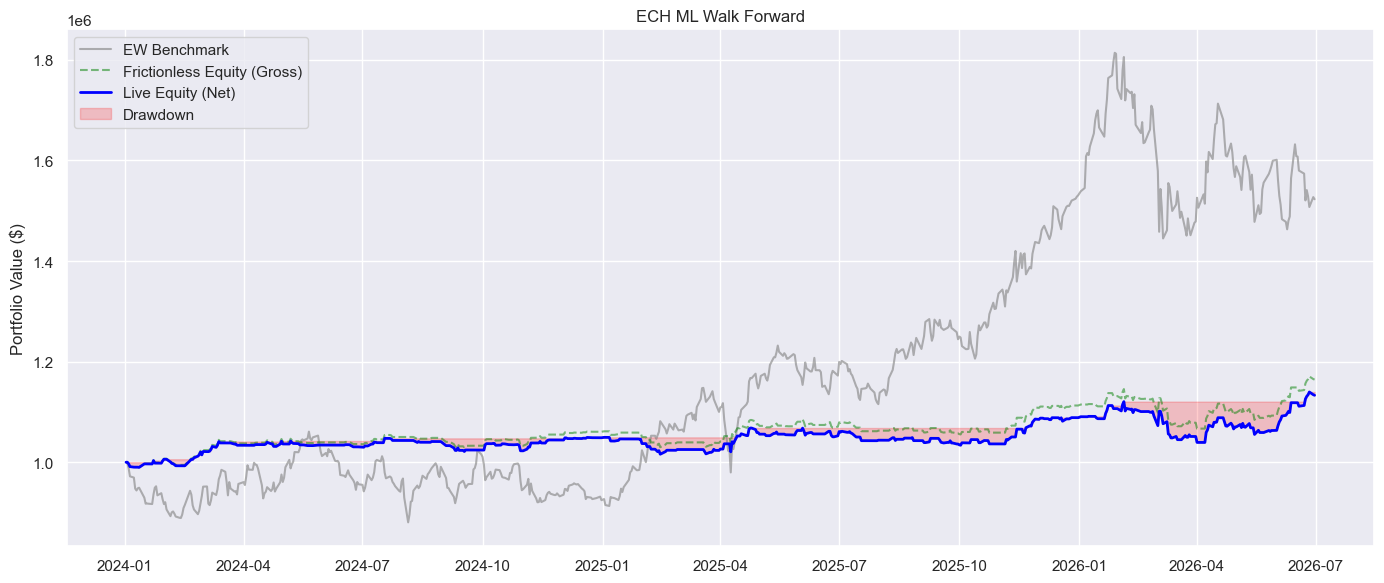

🧠 Predicting 2026-06-30 |  625/625 |  last: 18.05s |  elapsed: 95m 39.1s
✅ Prediction complete. Took 95m 57.5s


📊 --- QUICK PORTFOLIO RESULTS: ECH ML Walk Forward ---
   Frictionless Return:     16.39%
   Net Strategy Return:     13.18%  (EW Benchmark: 52.28%)
   Max Drawdown:            -6.43%
   Win Rate (Gross Bars):   26.1%   (EW Benchmark: 51.9%)
   Loss Rate (Gross Bars):  22.1%   (EW Benchmark: 46.8%)
   Zero Rate (Gross Bars):  51.8%    (EW Benchmark: 1.3%)
   Sharpe Ratio (Net):      0.91    (EW Benchmark: 0.81)
   Sortino/√2 (Net):        1.00    (EW Benchmark: 0.83)
   Total Fees Paid:         $32,104.36
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/research/Tearsheets/ECH_ML_Walk_Forward_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


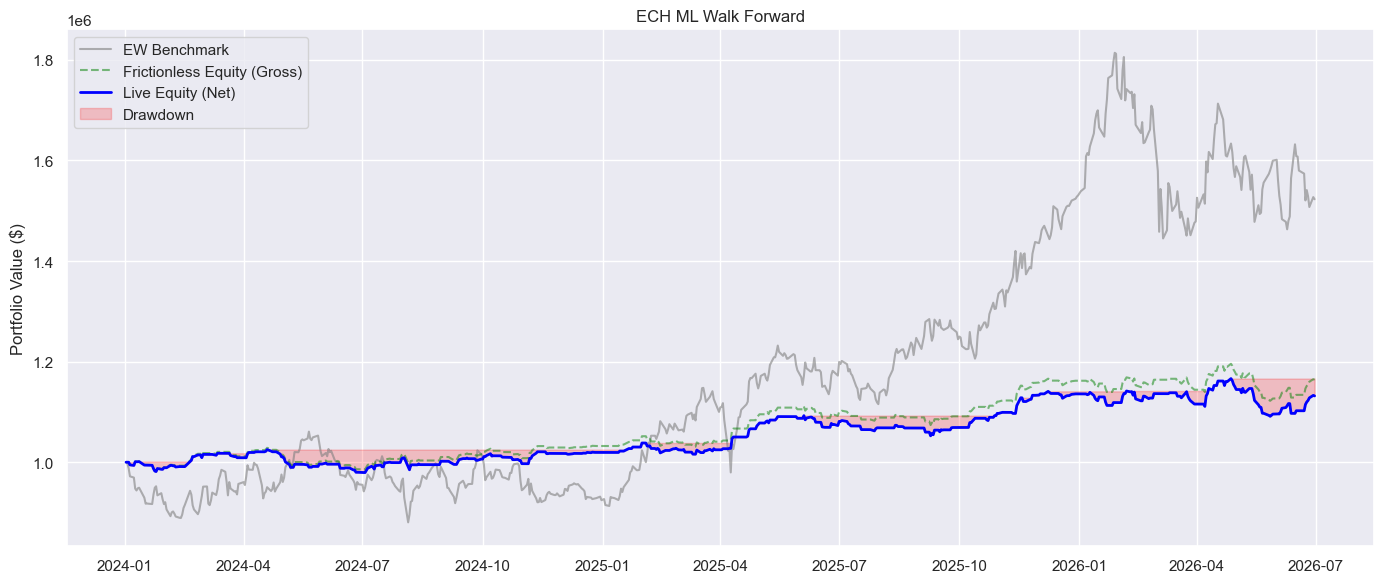

🧠 Predicting 2026-06-30 |  625/625 |  last: 16.61s |  elapsed: 96m 39.1s
✅ Prediction complete. Took 96m 55.8s


📊 --- QUICK PORTFOLIO RESULTS: ECH ML Walk Forward ---
   Frictionless Return:     4.89%
   Net Strategy Return:     4.00%  (EW Benchmark: 52.28%)
   Max Drawdown:            -2.63%
   Win Rate (Gross Bars):   5.9%   (EW Benchmark: 51.9%)
   Loss Rate (Gross Bars):  5.3%   (EW Benchmark: 46.8%)
   Zero Rate (Gross Bars):  88.8%    (EW Benchmark: 1.3%)
   Sharpe Ratio (Net):      0.49    (EW Benchmark: 0.81)
   Sortino/√2 (Net):        0.56    (EW Benchmark: 0.83)
   Total Fees Paid:         $8,959.97
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/research/Tearsheets/ECH_ML_Walk_Forward_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


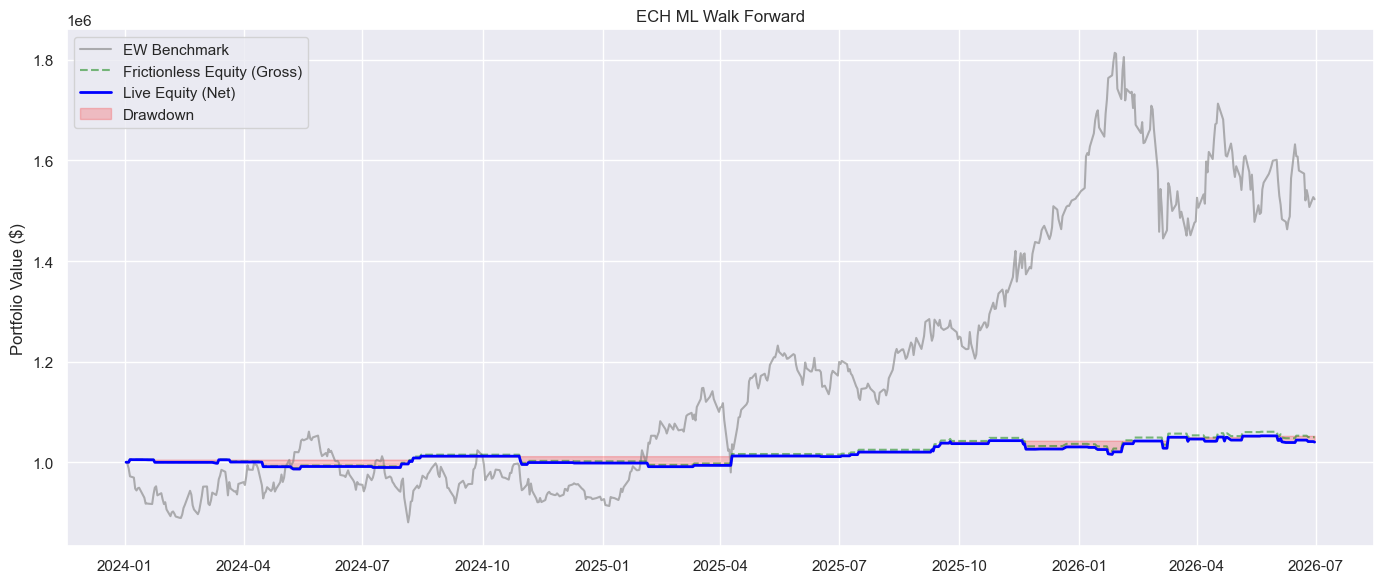


📊 --- QUICK PORTFOLIO RESULTS: ECH Combined PCA Strategy: Runs 9, 13, 14 ---
   Frictionless Return:     41.66%
   Net Strategy Return:     35.49%  (EW Benchmark: 52.28%)
   Max Drawdown:            -8.92%
   Win Rate (Gross Bars):   36.7%   (EW Benchmark: 51.9%)
   Loss Rate (Gross Bars):  30.4%   (EW Benchmark: 46.8%)
   Zero Rate (Gross Bars):  32.9%    (EW Benchmark: 1.3%)
   Sharpe Ratio (Net):      1.20    (EW Benchmark: 0.81)
   Sortino/√2 (Net):        1.45    (EW Benchmark: 0.83)
   Total Fees Paid:         $61,757.35
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/research/Tearsheets/ECH_Combined_PCA_Strategy:_Runs_9,_13,_14_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


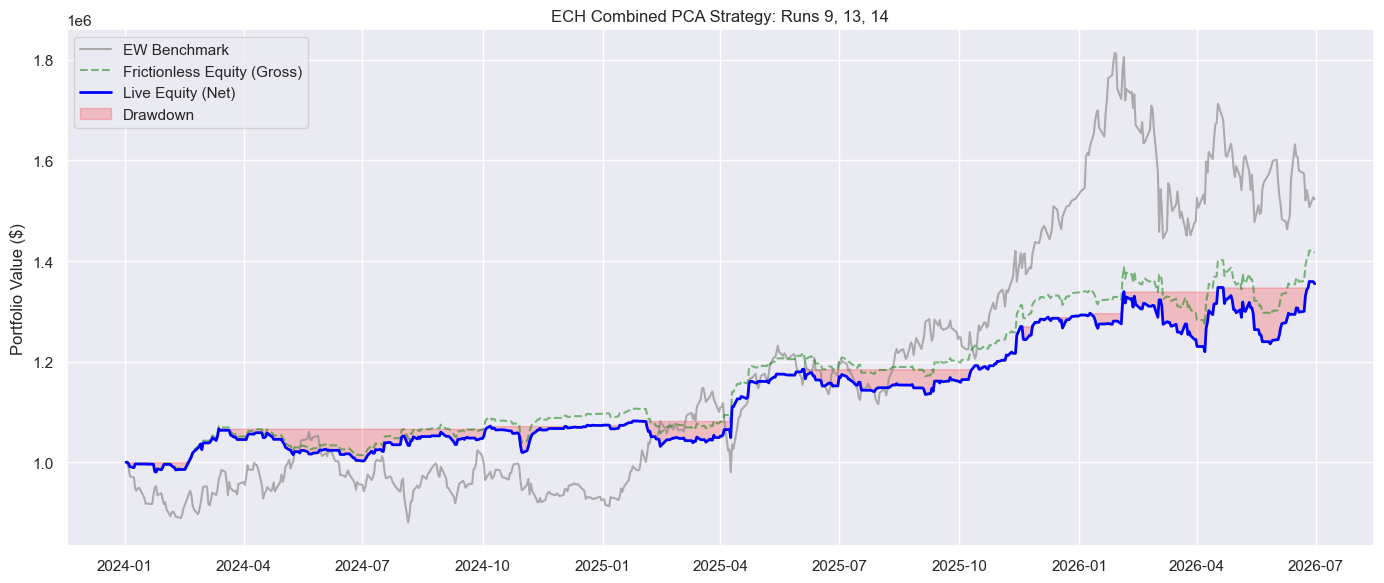

,ECH_scaler-standard_pca-0p8_sig-0p01,ECH_scaler-standard_pca-0p85_sig-0p01,ECH_scaler-standard_pca-0p85_sig-0p02
Timestamp,,,
2024-01-02,0.34,0.00,0.00
2024-01-03,0.34,0.33,-0.33
2024-01-04,0.34,0.33,0.00
2024-01-05,0.00,-0.33,0.00
2024-01-08,0.00,0.00,0.00


,ECH
Timestamp,
2024-01-02,0.34
2024-01-03,0.34
2024-01-04,0.67
2024-01-05,-0.33
2024-01-08,0.00


,gross_returns,gross_equity,total_costs_usd,cumulative_costs,net_equity,net_returns,cum_benchmark
Timestamp,,,,,,,
2026-06-24,0.009008,1.403840e+06,312.224257,61000.483801,1.342840e+06,0.009184,1.540950
2026-06-25,0.002723,1.407664e+06,103.467030,61103.950831,1.346560e+06,0.002770,1.528607
2026-06-26,0.009298,1.420753e+06,173.606131,61277.556962,1.359475e+06,0.009592,1.507393
2026-06-29,-0.000131,1.420567e+06,270.355376,61547.912338,1.359020e+06,-0.000335,1.527065
2026-06-30,-0.002778,1.416620e+06,209.433564,61757.345902,1.354863e+06,-0.003058,1.522822


In [16]:
from src.vector_backtester_Mateo import PortfolioVectorEngine

SYMBOL = "ECH"
COMMON_PARAMS["symbol"] = SYMBOL

combined_specs = [
    {
        "run_number": 9,
        "pca_scaler": "standard",
        "pca_n_components": 0.8,
        "signal_threshold": 0.01,
        "position_size": 0.34,
    },
    {
        "run_number": 13,
        "pca_scaler": "standard",
        "pca_n_components": 0.85,
        "signal_threshold": 0.01,
        "position_size": 0.33,
    },
    {
        "run_number": 14,
        "pca_scaler": "standard",
        "pca_n_components": 0.85,
        "signal_threshold": 0.02,
        "position_size": 0.33,
    },
]

combined_artifacts = {}
combined_weights_parts = []

for spec in combined_specs:
    run_id = make_run_id(
        SYMBOL,
        spec["pca_scaler"],
        spec["pca_n_components"],
        spec["signal_threshold"],
    )

    artifacts = run_single_case_PCA(
        symbol=SYMBOL,
        asset_class=ASSET_CLASS,
        # start_date=COMMON_PARAMS["start_date"],
        start_date="2024-01-01",
        # end_date=COMMON_PARAMS["end_date"],
        end_date="2026-07-01",
        signal_threshold=spec["signal_threshold"],
        pca_n_components=spec["pca_n_components"],
        pca_scaler=spec["pca_scaler"],
        training_years=COMMON_PARAMS["training_years"],
        sharpe_filter_enabled=COMMON_PARAMS["sharpe_filter_enabled"],
        feature_diagnostics_enabled=COMMON_PARAMS["feature_diagnostics_enabled"],
        feature_diagnostics_top_n=COMMON_PARAMS["feature_diagnostics_top_n"],
        position_size=spec["position_size"],
        initial_capital=INITIAL_CAPITAL,
        max_iter=COMMON_PARAMS["max_iter"],
        execution_delay=EXECUTION_DELAY,
        verbose=COMMON_PARAMS["verbose"],
        show_progress=True,
        show_tearsheet=True,
        return_artifacts=True,
    )

    artifacts["run_id"] = run_id
    artifacts["combined_weight"] = spec["position_size"]
    combined_artifacts[run_id] = artifacts

    combined_weights_parts.append(
        artifacts["weights"].rename(columns={SYMBOL: run_id})
    )

combined_component_weights = pd.concat(combined_weights_parts, axis=1).fillna(0)
combined_weights = pd.DataFrame(
    {SYMBOL: combined_component_weights.sum(axis=1)},
    index=combined_component_weights.index,
)

combined_prices = (
    next(iter(combined_artifacts.values()))["dataset"][["Open"]]
    .rename(columns={"Open": SYMBOL})
    .loc[combined_weights.index]
)

combined_engine = PortfolioVectorEngine(
    prices=combined_prices,
    signals=combined_weights,
    asset_class=ASSET_CLASS,
    initial_capital=INITIAL_CAPITAL,
    execution_delay=EXECUTION_DELAY,
)

combined_stats = combined_engine.run()
combined_engine.tearsheet("ECH Combined PCA Strategy: Runs 9, 13, 14")

combined_strategy_artifacts = {
    "symbol": SYMBOL,
    "specs": combined_specs,
    "component_artifacts": combined_artifacts,
    "component_weights": combined_component_weights,
    "weights": combined_weights,
    "prices": combined_prices,
    "engine": combined_engine,
    "stats": combined_stats,
}

display(combined_component_weights.head())
display(combined_weights.head())
display(combined_stats.tail())